### **Time Series Forecasting**


In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (20, 6)

In [77]:
mobile_sales = pd.read_excel('data/mobilesales.xlsx')
mobile_sales.head()

,DATE,Sales
0,2001-01-01,6519.0
1,2001-02-01,6654.0
2,2001-03-01,7332.0
3,2001-04-01,7332.0
4,2001-05-01,8240.0


In [78]:
mobile_sales.dtypes

DATE     datetime64[ns]
Sales           float64
dtype: object

In [79]:
mobile_sales.Sales.describe()

count      198.000000
mean     10842.757576
std       2605.006293
min        108.000000
25%       8856.000000
50%      10745.000000
75%      12399.750000
max      23740.000000
Name: Sales, dtype: float64

In [80]:
mobile_sales.DATE.describe()

count                              217
mean     2009-12-31 04:25:26.267281152
min                2001-01-01 00:00:00
25%                2005-07-01 00:00:00
50%                2010-01-01 00:00:00
75%                2014-07-01 00:00:00
max                2019-01-01 00:00:00
Name: DATE, dtype: object

In [81]:
18*12 + 1

217

In [82]:
mobile_sales.columns

Index(['DATE', 'Sales'], dtype='object')

In [83]:
mobile_sales.set_index('DATE', inplace=True)

In [84]:
mobile_sales.head()

,Sales
DATE,
2001-01-01,6519.0
2001-02-01,6654.0
2001-03-01,7332.0
2001-04-01,7332.0
2001-05-01,8240.0


<Axes: xlabel='DATE'>

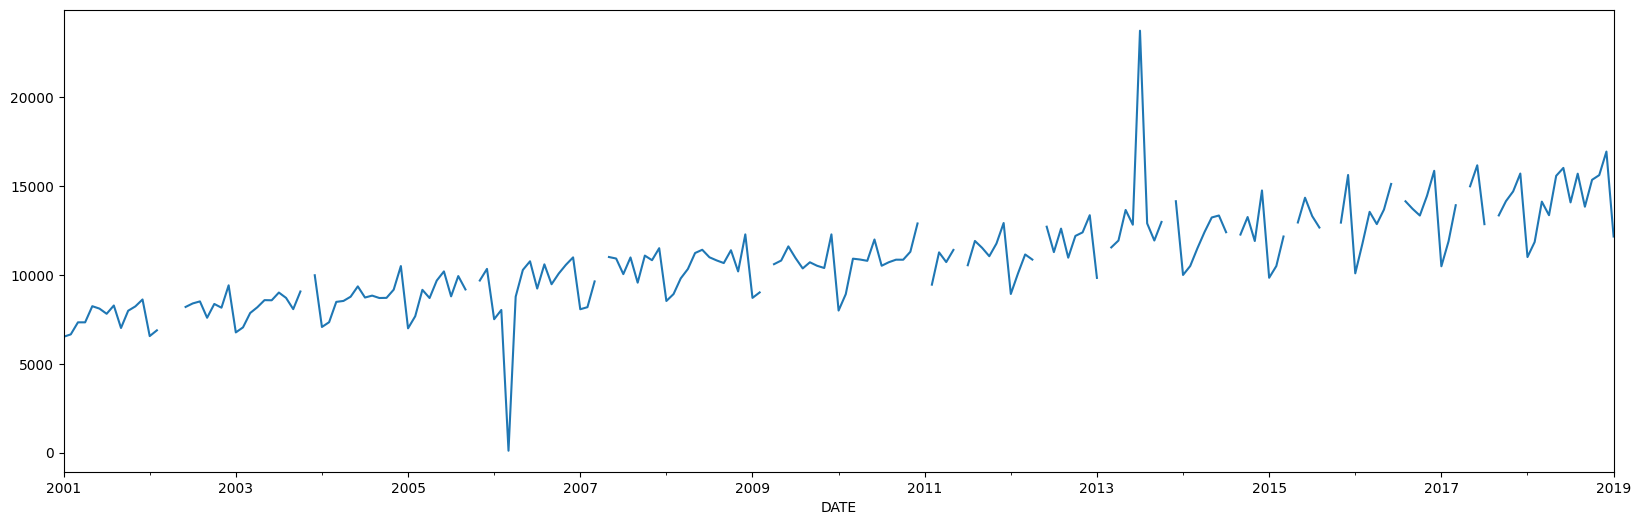

In [85]:
mobile_sales['Sales'].plot()

In [86]:
mobile_sales['Sales'].mean()

np.float64(10842.757575757576)

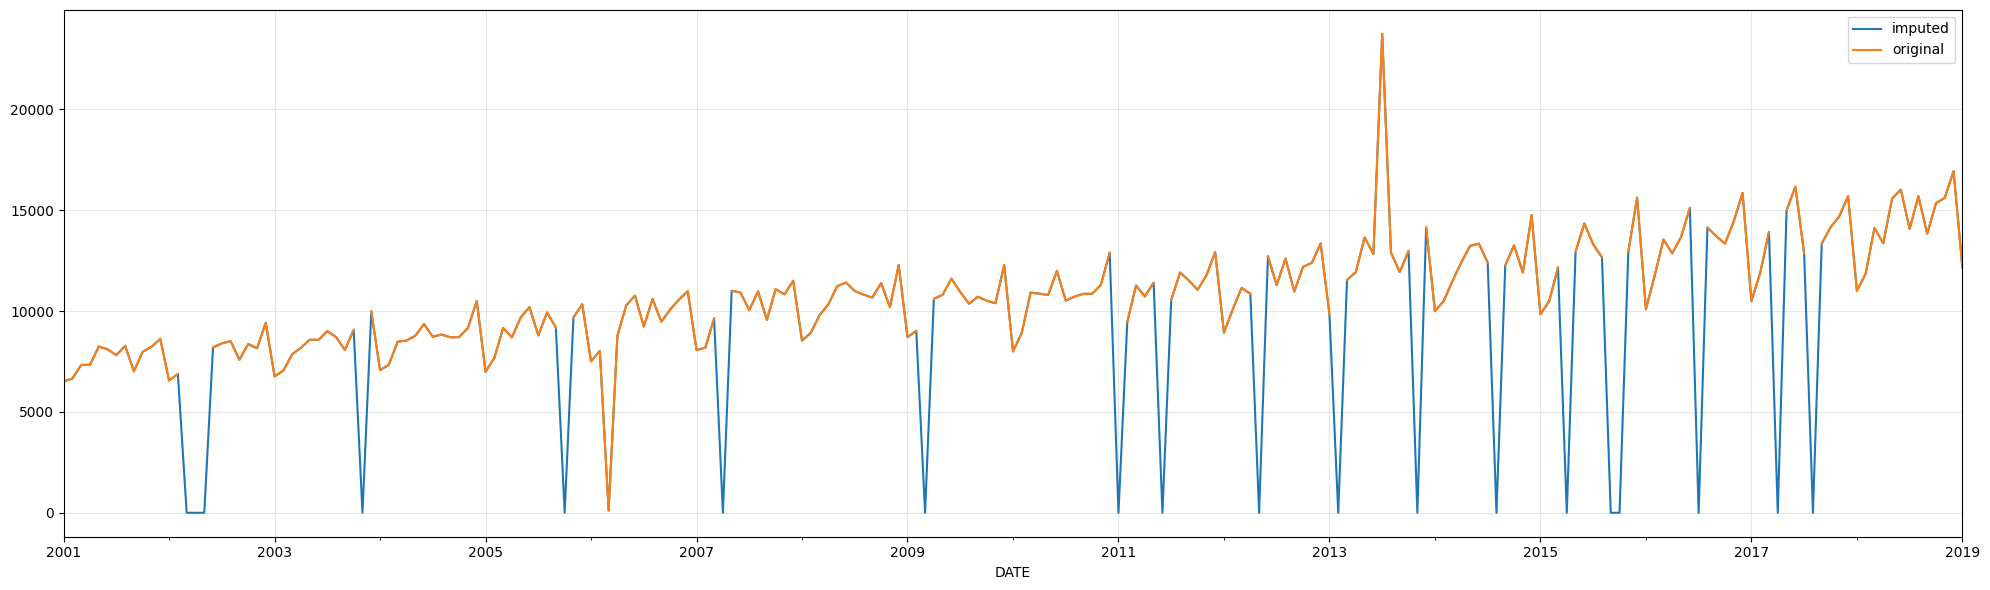

In [87]:
mobile_sales['Sales'].fillna(0).plot(label='imputed')
mobile_sales['Sales'].plot(label='original')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Linear interpolation

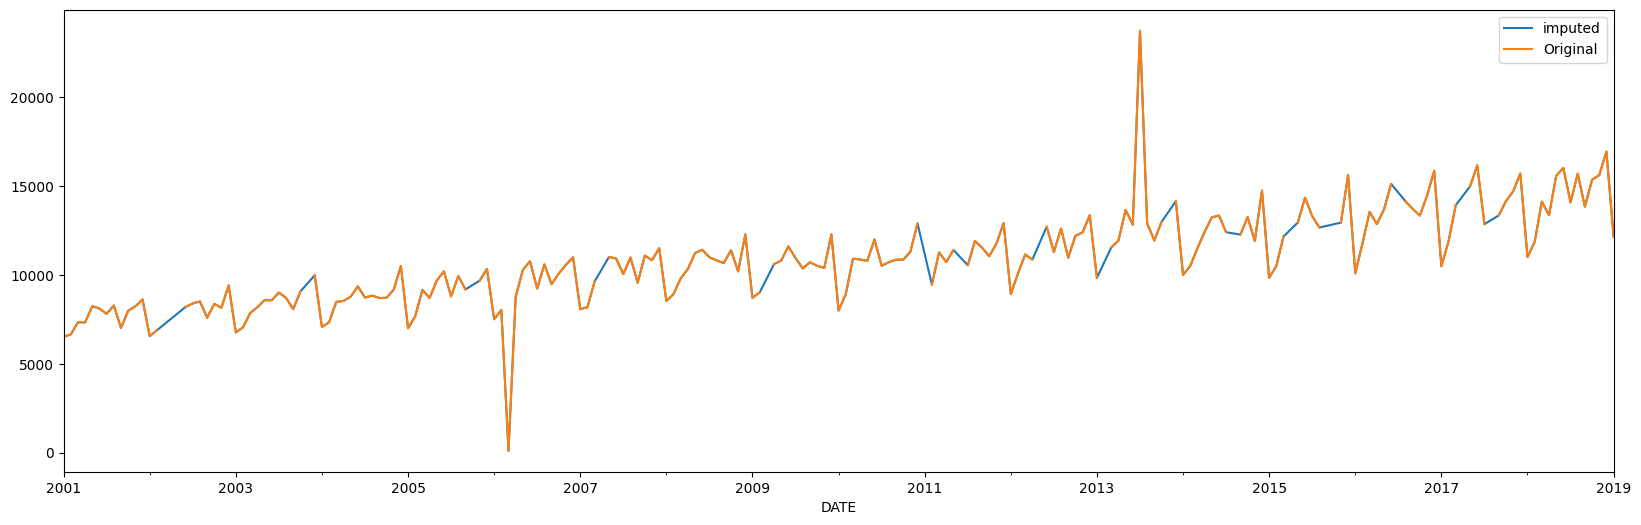

In [88]:
mobile_sales['Sales'].interpolate(method="linear").plot(label="imputed")
mobile_sales['Sales'].plot(label="Original")
plt.legend()

In [89]:
mobile_sales['Sales'] = mobile_sales['Sales'].interpolate(method='linear')

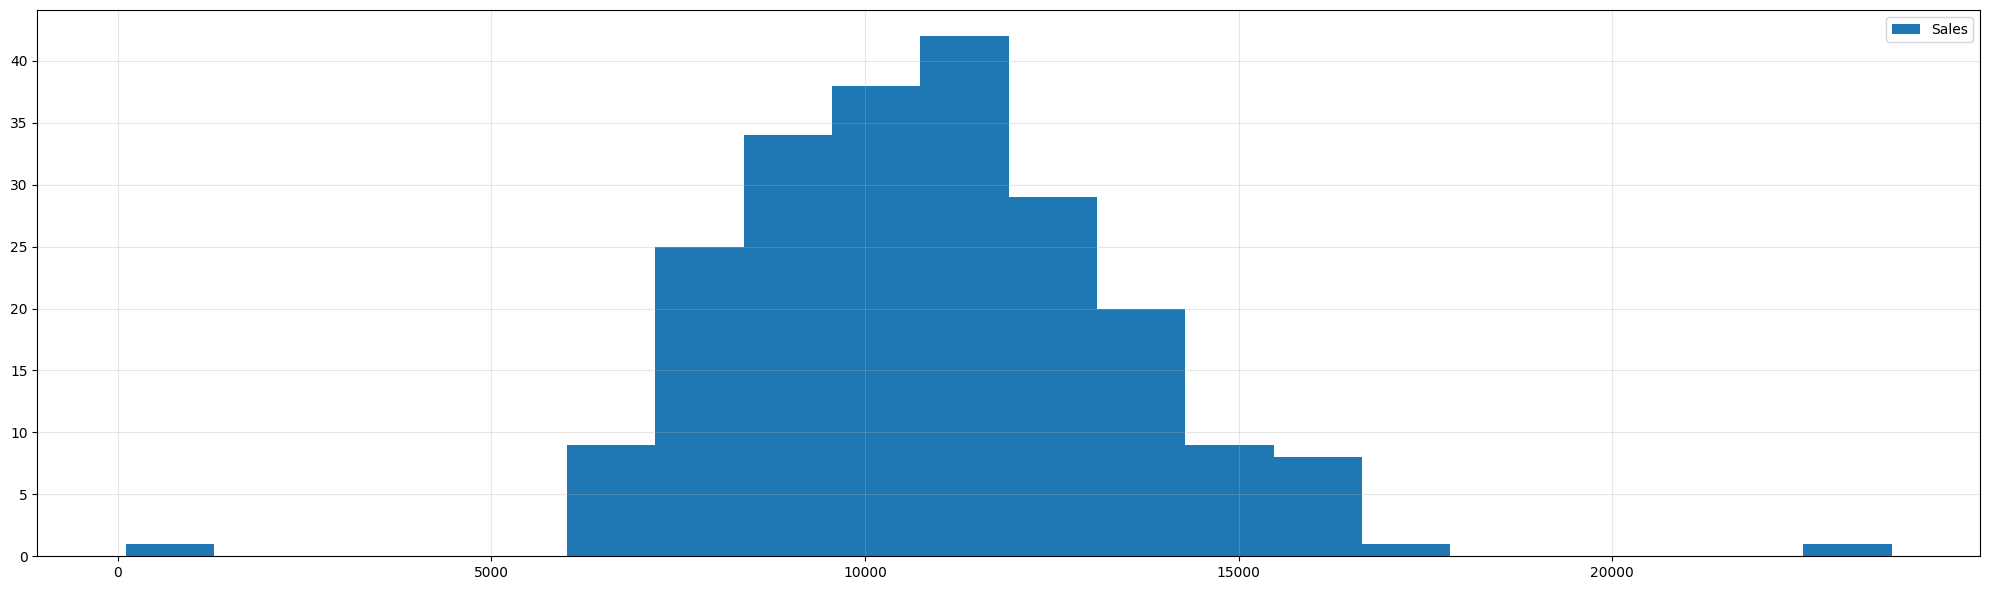

In [90]:
mobile_sales.Sales.hist(bins=20)
plt.legend(['Sales'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [91]:
mobile_sales.Sales.quantile(0.995)

np.float64(16879.15999999999)

In [92]:
mobile_sales.Sales.quantile(0.005)

np.float64(6522.12)

In [93]:
mobile_sales['Sales'] = mobile_sales['Sales'].clip(
    lower=mobile_sales['Sales'].quantile(0.01),
    upper=mobile_sales['Sales'].quantile(0.99)
)

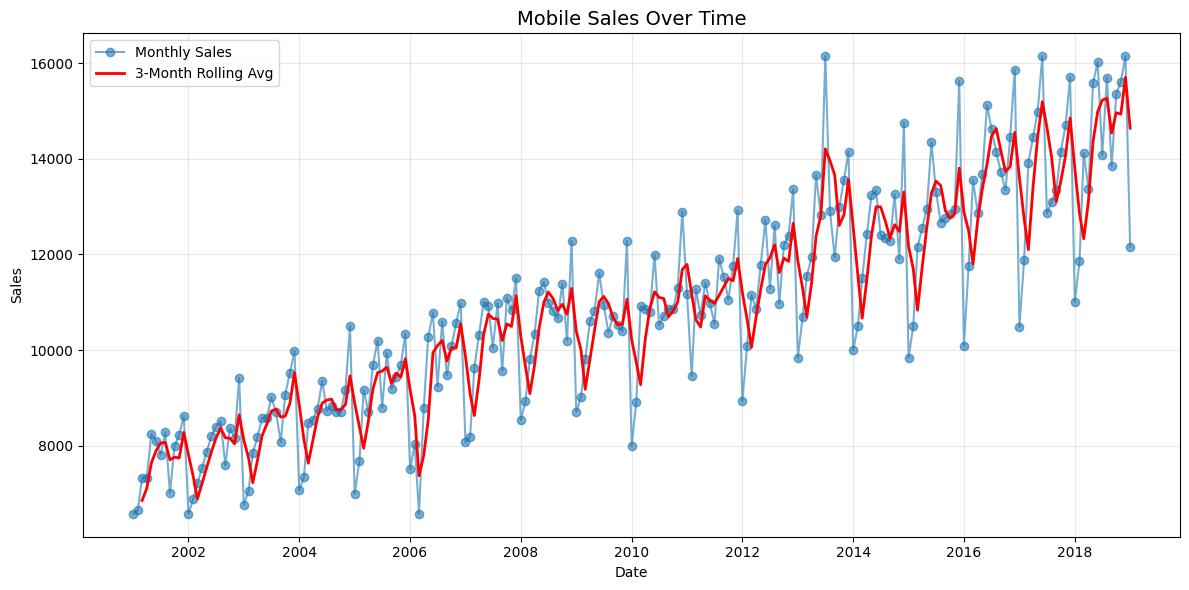

In [94]:
mobile_sales = pd.read_excel('data/mobilesales.xlsx')

# Ensure DATE column is datetime
mobile_sales['DATE'] = pd.to_datetime(mobile_sales['DATE'])
mobile_sales.set_index('DATE', inplace=True)

# Handle missing values with interpolation
mobile_sales['Sales'] = mobile_sales['Sales'].interpolate(method='linear')

# Remove extreme outliers (1st to 99th percentile)
q_low, q_high = mobile_sales['Sales'].quantile([0.01, 0.99])
mobile_sales['Sales'] = mobile_sales['Sales'].clip(lower=q_low, upper=q_high)

# Add rolling average (trend smoothing)
mobile_sales['Rolling_3M'] = mobile_sales['Sales'].rolling(window=3).mean()

# Plot
plt.figure(figsize=(12,6))
plt.plot(mobile_sales.index, mobile_sales['Sales'], '-o', alpha=0.6, label='Monthly Sales')
plt.plot(mobile_sales.index, mobile_sales['Rolling_3M'], color='red', linewidth=2, label='3-Month Rolling Avg')
plt.title('Mobile Sales Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


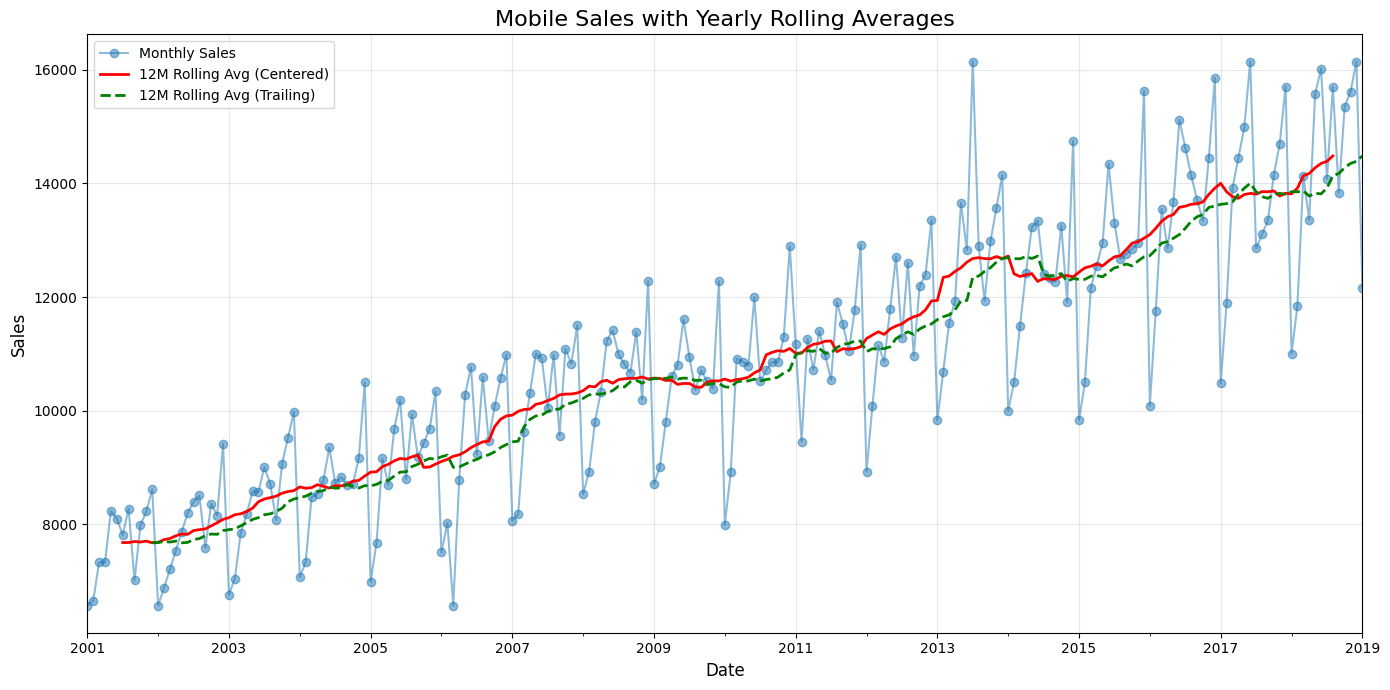

In [95]:
plt.figure(figsize=(14,7))

# Raw sales
mobile_sales['Sales'].plot(style='-o', alpha=0.5, label='Monthly Sales')

# Yearly rolling averages
mobile_sales['Sales'].rolling(12, center=True).mean().plot(
    linewidth=2, color='red', label='12M Rolling Avg (Centered)')

mobile_sales['Sales'].rolling(12, center=False).mean().plot(
    linewidth=2, linestyle='--', color='green', label='12M Rolling Avg (Trailing)')


# Styling
plt.title('Mobile Sales with Yearly Rolling Averages', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### Decomposition

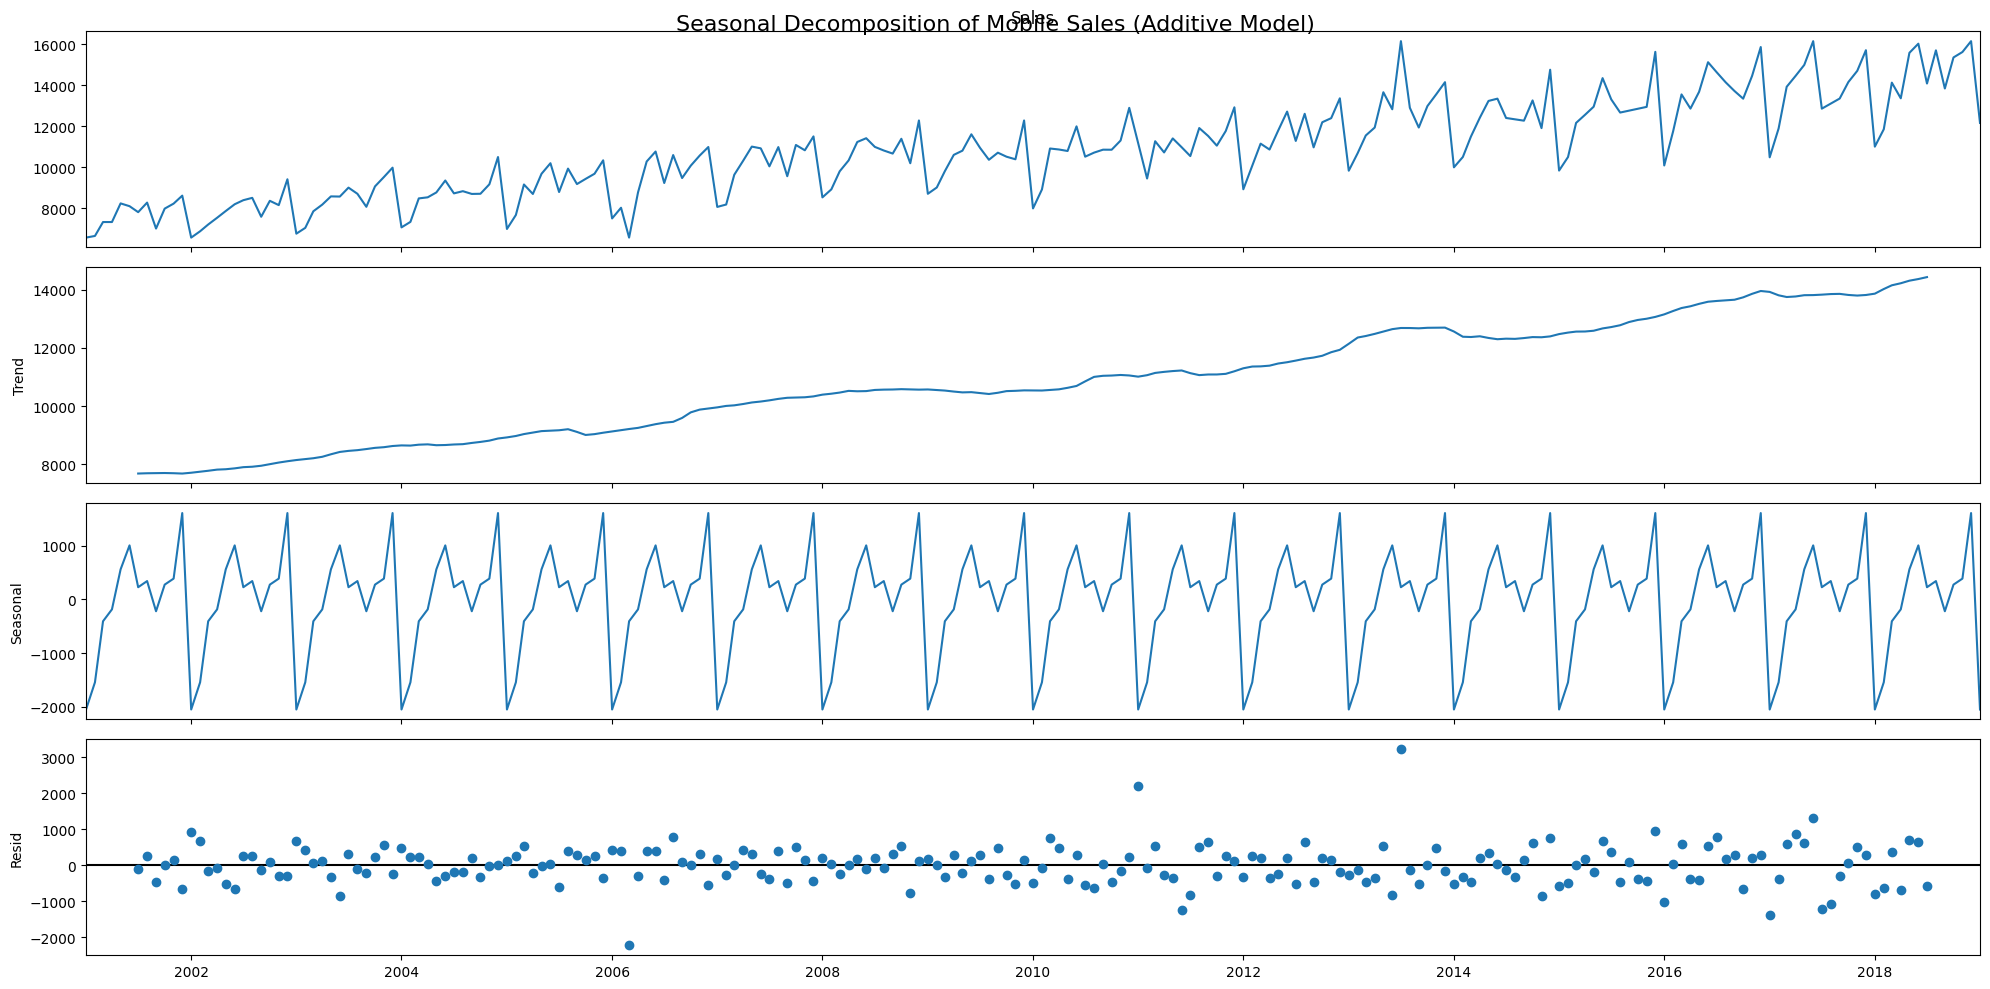

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Seasonal decomposition (Additive Model)
model = sm.tsa.seasonal_decompose(mobile_sales['Sales'], model='additive')

# Plot
plt.rcParams['figure.figsize'] = (20, 10)
model.plot()
plt.suptitle('Seasonal Decomposition of Mobile Sales (Additive Model)', fontsize=16)
plt.show()


In [97]:
model.observed

DATE
2001-01-01     6573.36
2001-02-01     6654.00
2001-03-01     7332.00
2001-04-01     7332.00
2001-05-01     8240.00
                ...   
2018-09-01    13838.00
2018-10-01    15351.00
2018-11-01    15615.00
2018-12-01    16144.48
2019-01-01    12160.00
Name: Sales, Length: 217, dtype: float64

In [98]:
model.trend

DATE
2001-01-01   NaN
2001-02-01   NaN
2001-03-01   NaN
2001-04-01   NaN
2001-05-01   NaN
              ..
2018-09-01   NaN
2018-10-01   NaN
2018-11-01   NaN
2018-12-01   NaN
2019-01-01   NaN
Name: trend, Length: 217, dtype: float64

In [99]:
model.seasonal

DATE
2001-01-01   -2050.092675
2001-02-01   -1543.537871
2001-03-01    -406.717675
2001-04-01    -185.047675
2001-05-01     559.648403
                 ...     
2018-09-01    -220.153067
2018-10-01     275.270952
2018-11-01     387.418011
2018-12-01    1608.209678
2019-01-01   -2050.092675
Name: seasonal, Length: 217, dtype: float64

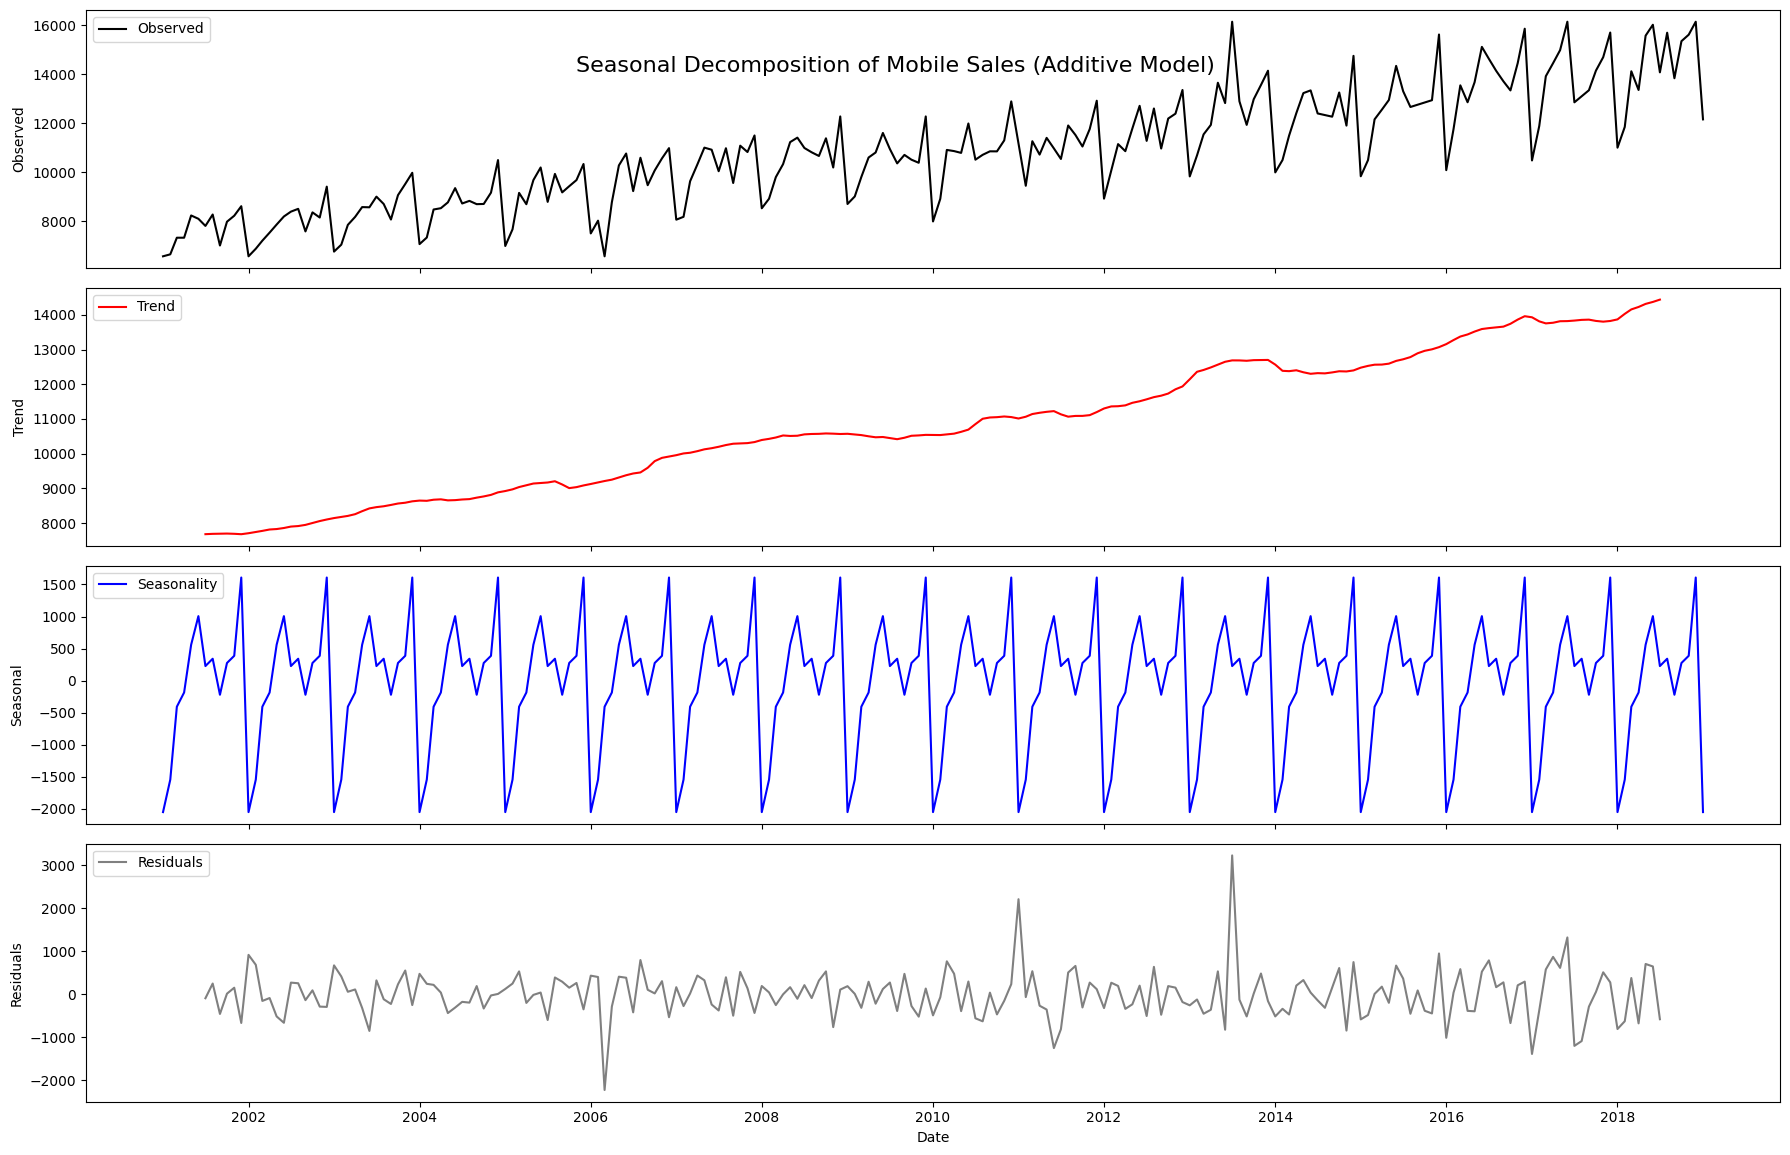

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Seasonal decomposition (Additive Model)
result = sm.tsa.seasonal_decompose(mobile_sales['Sales'], model='additive')

# Custom plotting
fig, axes = plt.subplots(4, 1, figsize=(18, 12), sharex=True)

# Observed
axes[0].plot(result.observed, label='Observed', color='black')
axes[0].legend(loc='upper left')
axes[0].set_ylabel("Observed")

# Trend
axes[1].plot(result.trend, label='Trend', color='red')
axes[1].legend(loc='upper left')
axes[1].set_ylabel("Trend")

# Seasonality
axes[2].plot(result.seasonal, label='Seasonality', color='blue')
axes[2].legend(loc='upper left')
axes[2].set_ylabel("Seasonal")

# Residual
axes[3].plot(result.resid, label='Residuals', color='gray')
axes[3].legend(loc='upper left')
axes[3].set_ylabel("Residuals")

plt.suptitle("Seasonal Decomposition of Mobile Sales (Additive Model)", fontsize=16, y=0.92)
plt.xlabel("Date")
plt.tight_layout()
plt.show()


### Decomposition from Scratch

**Trend_temp**

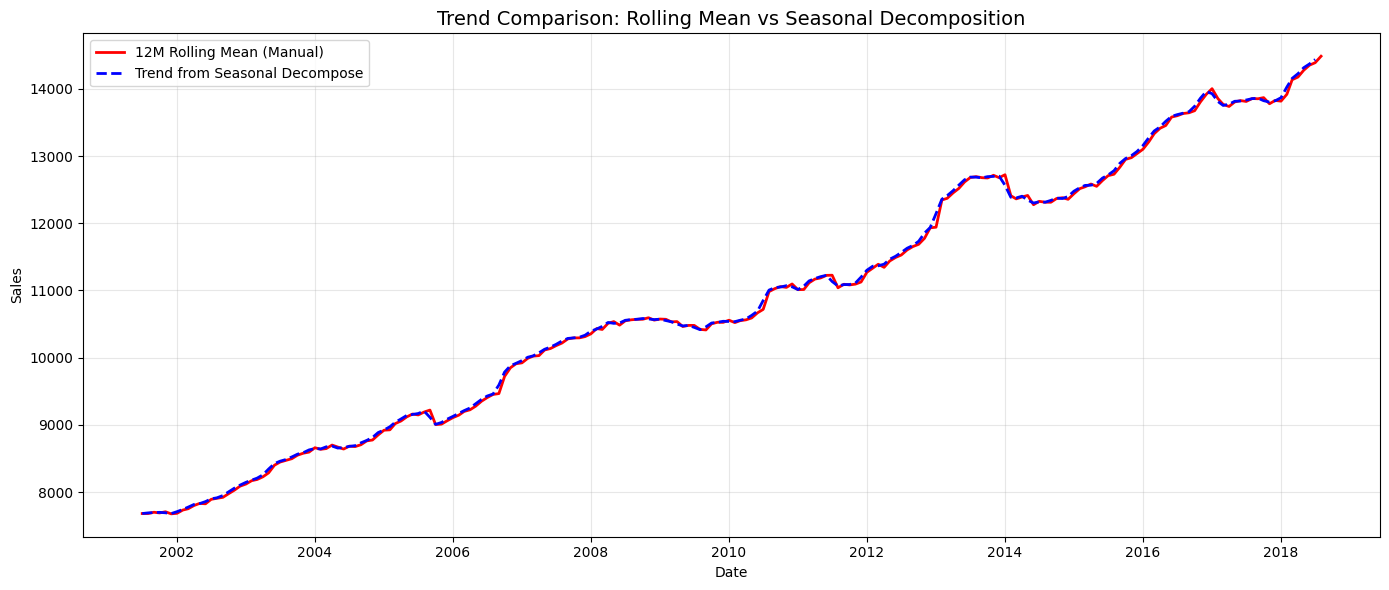

In [101]:
# Calculate 12-month rolling mean (your trend)
trend_manual = mobile_sales['Sales'].rolling(12, center=True).mean()

plt.figure(figsize=(14,6))

# Plot manual rolling trend
plt.plot(trend_manual, label='12M Rolling Mean (Manual)', color='red', linewidth=2)

# Plot decomposition trend
plt.plot(model.trend, label='Trend from Seasonal Decompose', color='blue', linestyle='--', linewidth=2)

plt.title('Trend Comparison: Rolling Mean vs Seasonal Decomposition', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


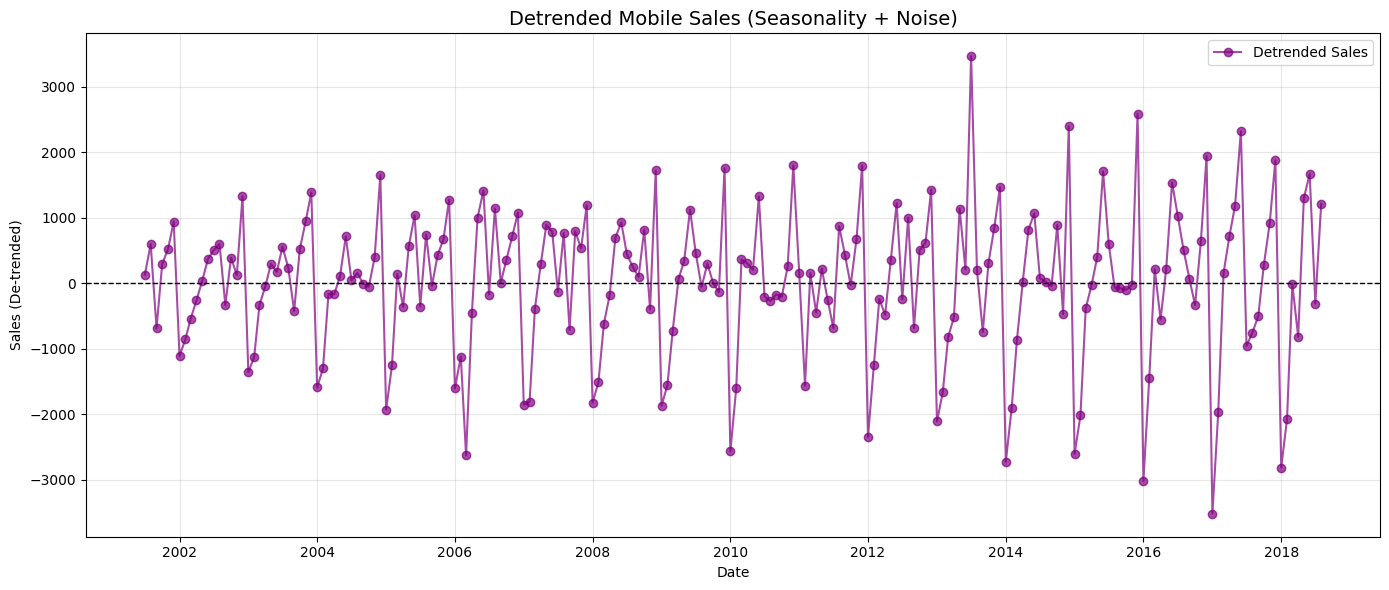

In [102]:
plt.figure(figsize=(14,6))

# Detrend
de_trend = mobile_sales['Sales'] - trend_manual
plt.plot(de_trend, '-o', color='purple', alpha=0.7, label='Detrended Sales')

plt.axhline(0, color='black', linestyle='--', linewidth=1)  # baseline
plt.title('Detrended Mobile Sales (Seasonality + Noise)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales (De-trended)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


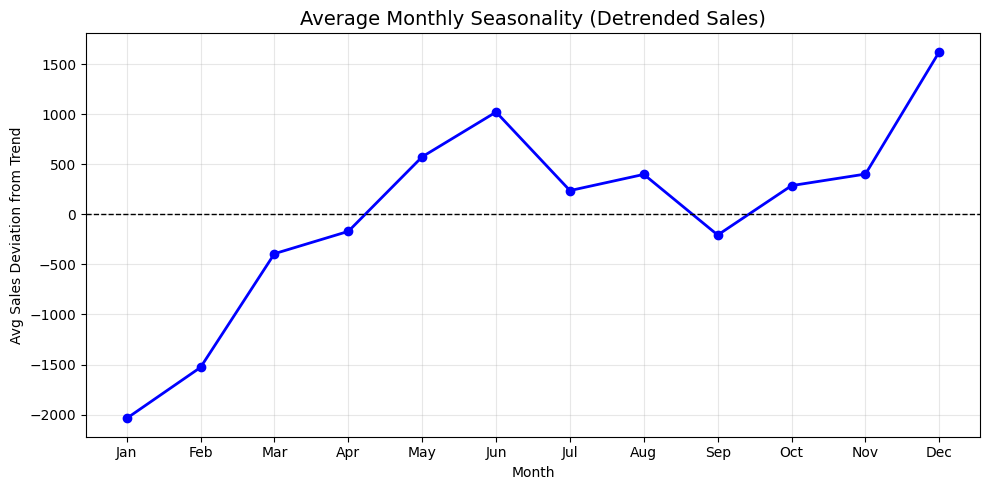

In [103]:
dtf = de_trend.reset_index()

monthly_seasonality = dtf.groupby(dtf['DATE'].dt.month)['Sales'].mean()

plt.figure(figsize=(10,5))
monthly_seasonality.plot(style='-o', color='blue', linewidth=2, markersize=6)

plt.title('Average Monthly Seasonality (Detrended Sales)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Avg Sales Deviation from Trend')
plt.xticks(range(1,13), 
           ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


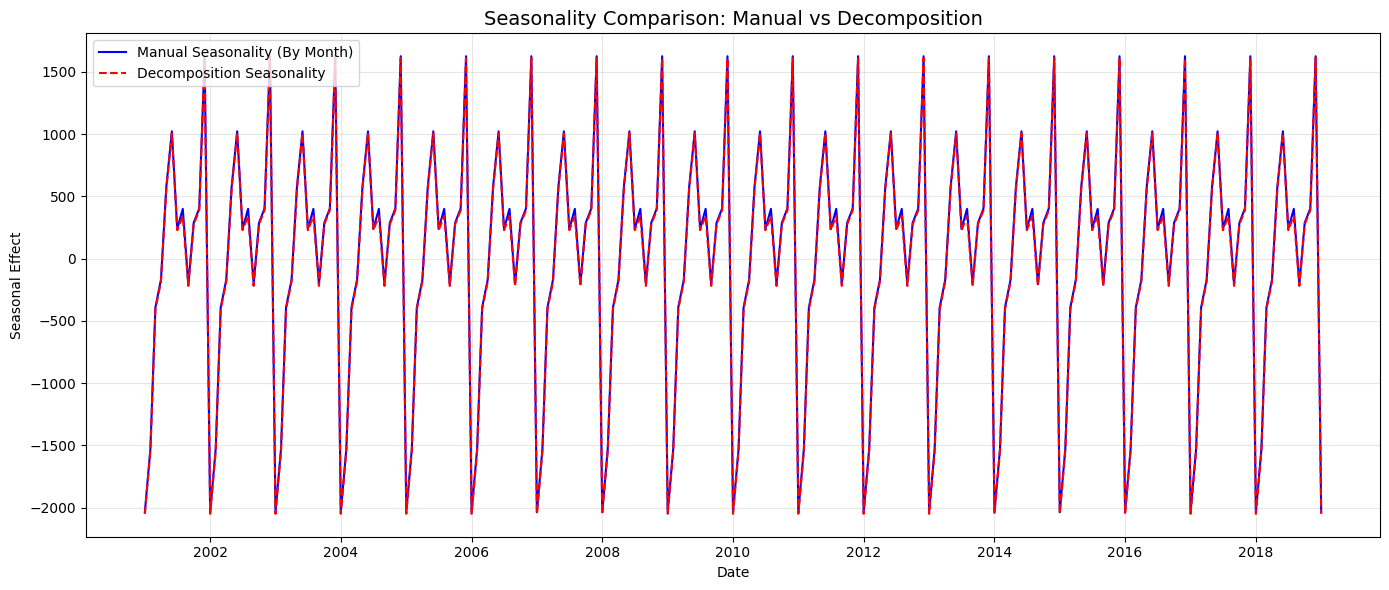

In [104]:
plt.figure(figsize=(14,6))

# Manual seasonality reconstruction
seasonal_manual = dtf.groupby(dtf['DATE'].dt.month)['Sales'].transform('mean')
plt.plot(dtf['DATE'], seasonal_manual, label='Manual Seasonality (By Month)', color='blue')

# Statsmodels seasonal component
plt.plot(model.seasonal, label='Decomposition Seasonality', color='red', linestyle='--')

plt.title('Seasonality Comparison: Manual vs Decomposition', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Seasonal Effect')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


----

In [105]:
from sklearn.metrics import (
    mean_squared_error as mse,
    mean_absolute_error as mae, 
    mean_absolute_percentage_error as mape
)

# Creating a function to print values of all these metrics.
def performance(actual, predicted):
    print('MAE :', round(mae(actual, predicted), 3))
    print('RMSE :', round(mse(actual, predicted)**0.5, 3)) 
    print('MAPE:', round(mape(actual, predicted), 3))

In [106]:
train_x = mobile_sales.loc[mobile_sales.index < mobile_sales.index[-12]].copy()
test_x = mobile_sales.loc[mobile_sales.index >= mobile_sales.index[-12]].copy()

test_x

,Sales,Rolling_3M
DATE,,
2018-02-01,11852.00,12853.666667
2018-03-01,14123.00,12326.666667
2018-04-01,13360.00,13111.666667
2018-05-01,15576.00,14353.000000
2018-06-01,16021.00,14985.666667
2018-07-01,14080.00,15225.666667
2018-08-01,15697.00,15266.000000
2018-09-01,13838.00,14538.333333
2018-10-01,15351.00,14962.000000


### Niave Mehtod

C:\Users\Admin\AppData\Local\Temp\ipykernel_17744\4076091452.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_x['pred'] = train_x['Sales'][-1]


MAE : 3479.79
RMSE : 3757.483
MAPE: 0.232


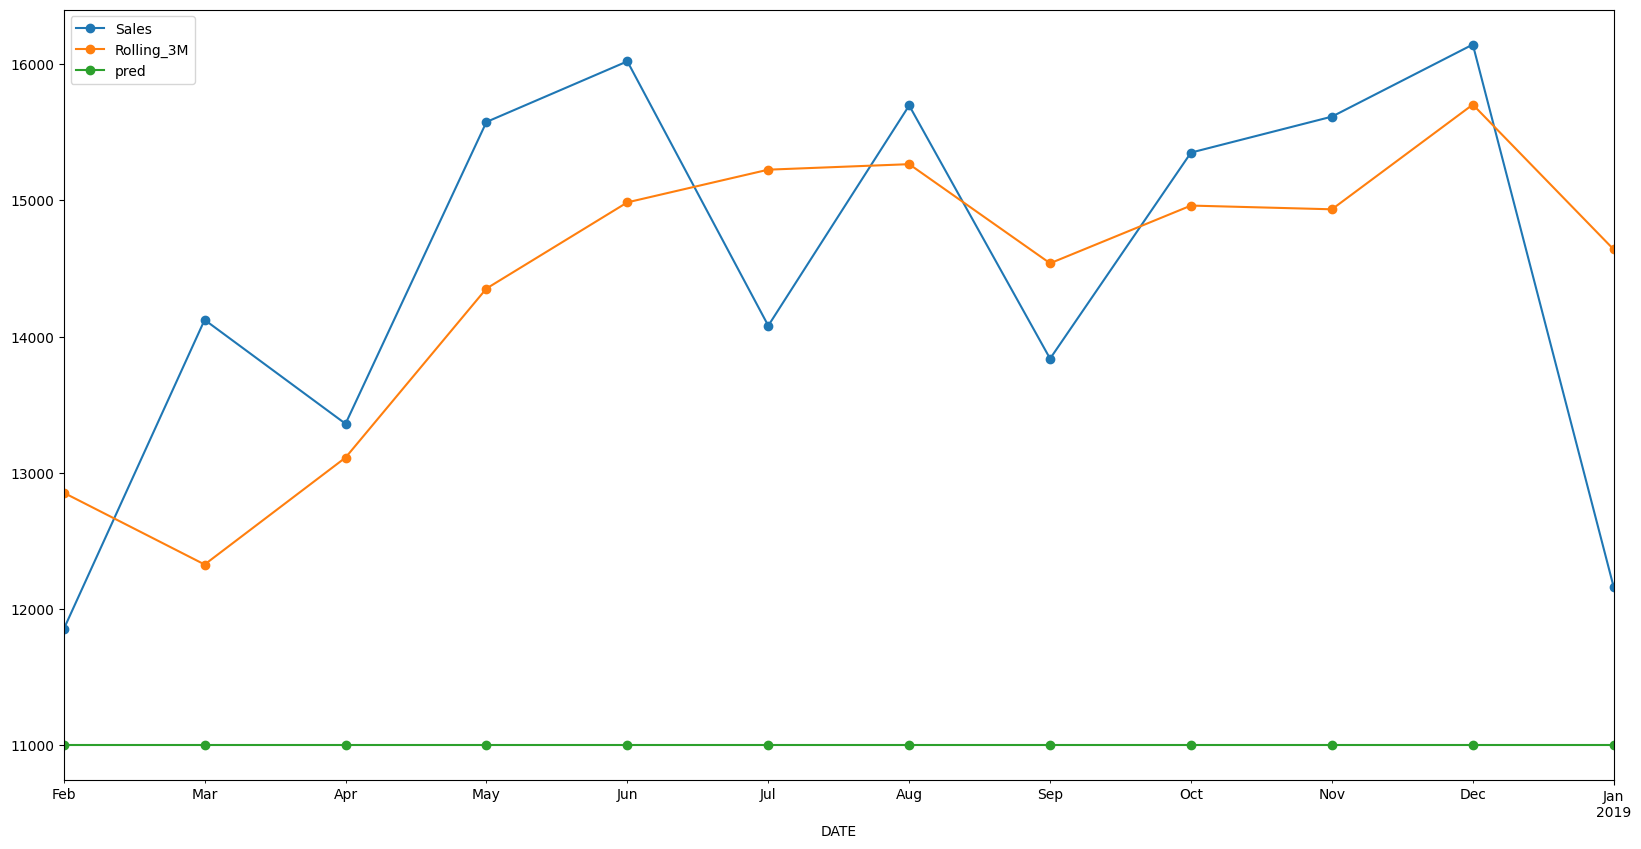

In [107]:
test_x['pred'] = train_x['Sales'][-1]

test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

### Mean method

MAE : 3832.336
RMSE : 4086.14
MAPE: 0.257


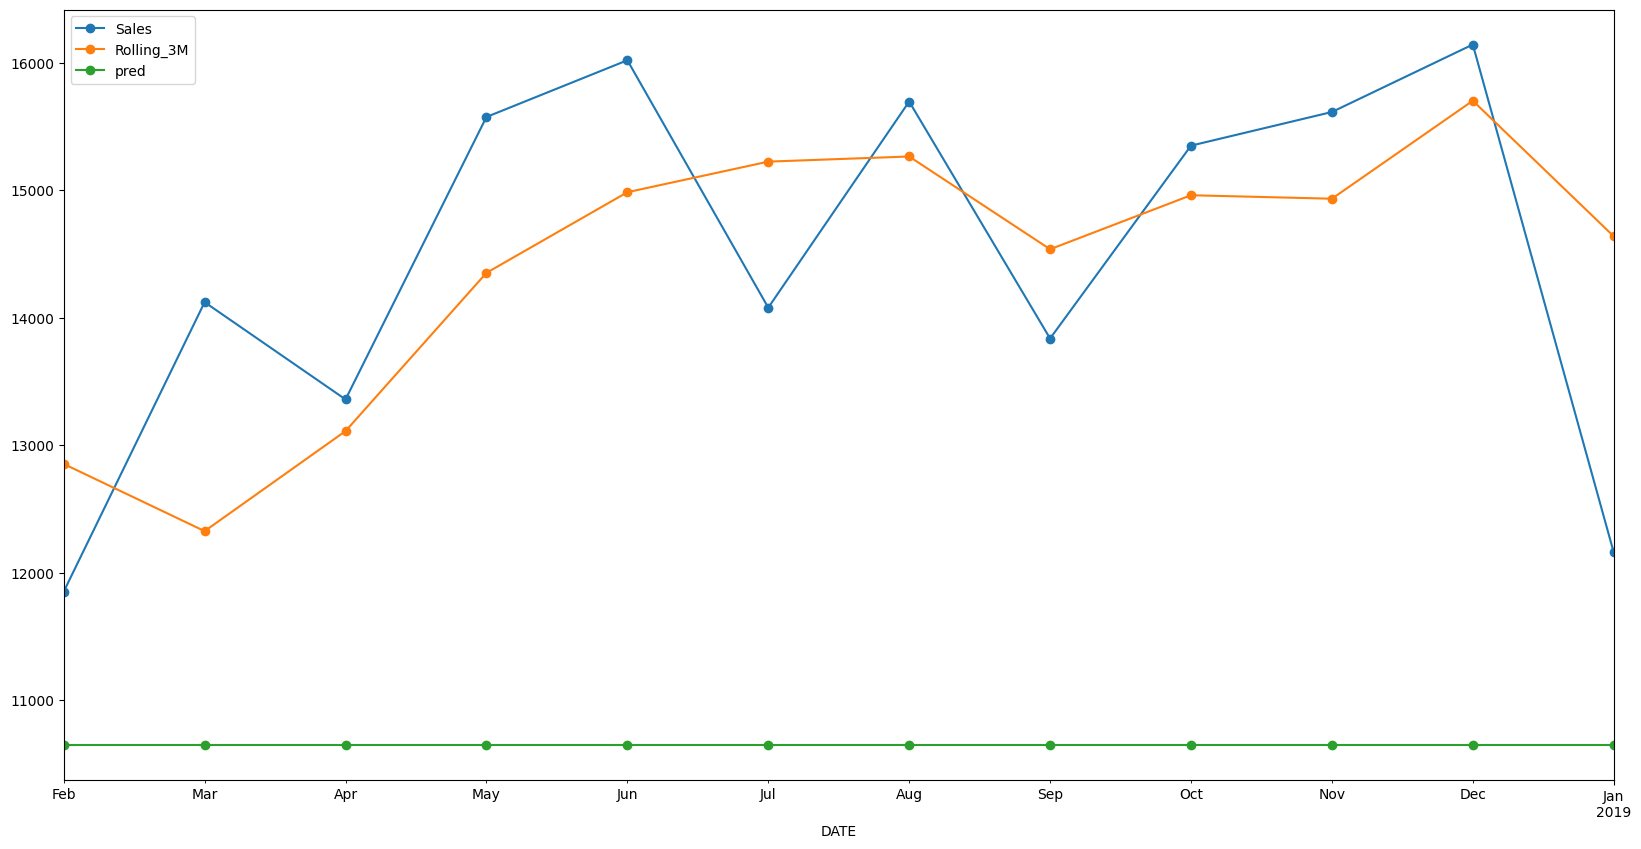

In [108]:
test_x['pred'] = train_x['Sales'].mean()

test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

### Seasonal Naive

In [109]:
test_x.index

DatetimeIndex(['2018-02-01', '2018-03-01', '2018-04-01', '2018-05-01',
               '2018-06-01', '2018-07-01', '2018-08-01', '2018-09-01',
               '2018-10-01', '2018-11-01', '2018-12-01', '2019-01-01'],
              dtype='datetime64[ns]', name='DATE', freq=None)

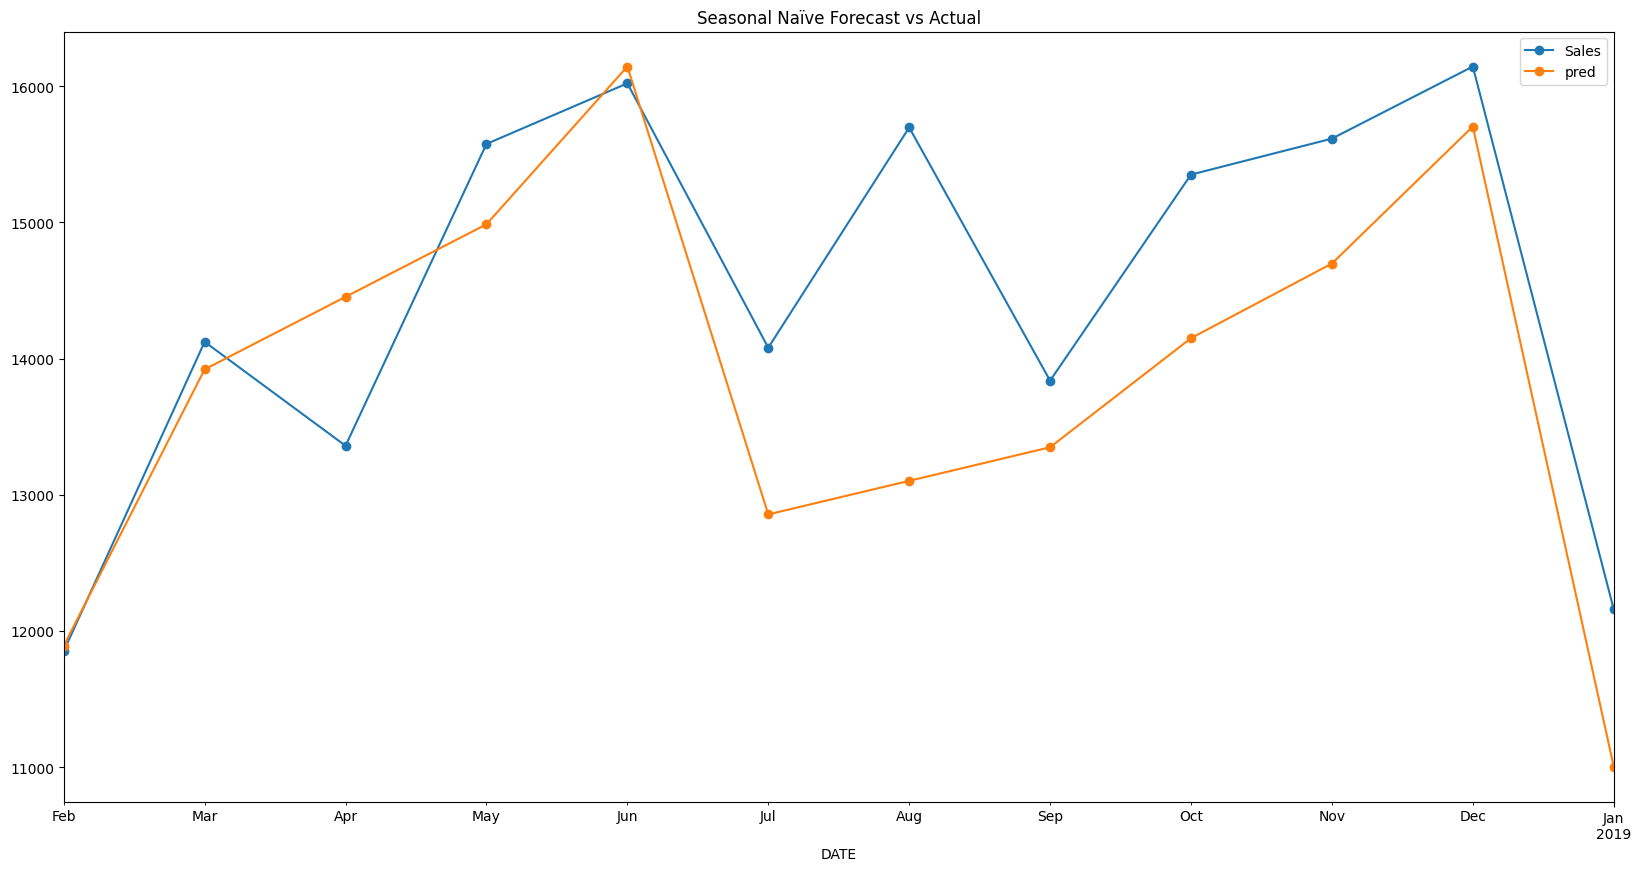

MAE : 839.08
RMSE : 1075.542
MAPE: 0.058


In [110]:
for i in test_x.index:
    prev_year = i - pd.DateOffset(years=1)
    if prev_year in train_x.index:  # make sure the date exists
        test_x.loc[i, 'pred'] = train_x.loc[prev_year, 'Sales']

# Plot
test_x[['Sales', 'pred']].plot(style='-o')
plt.title("Seasonal Naïve Forecast vs Actual")
plt.show()

# Evaluate
performance(test_x['Sales'], test_x['pred'])


### Drift Method

MAE : 3360.892
RMSE : 3640.673
MAPE: 0.224


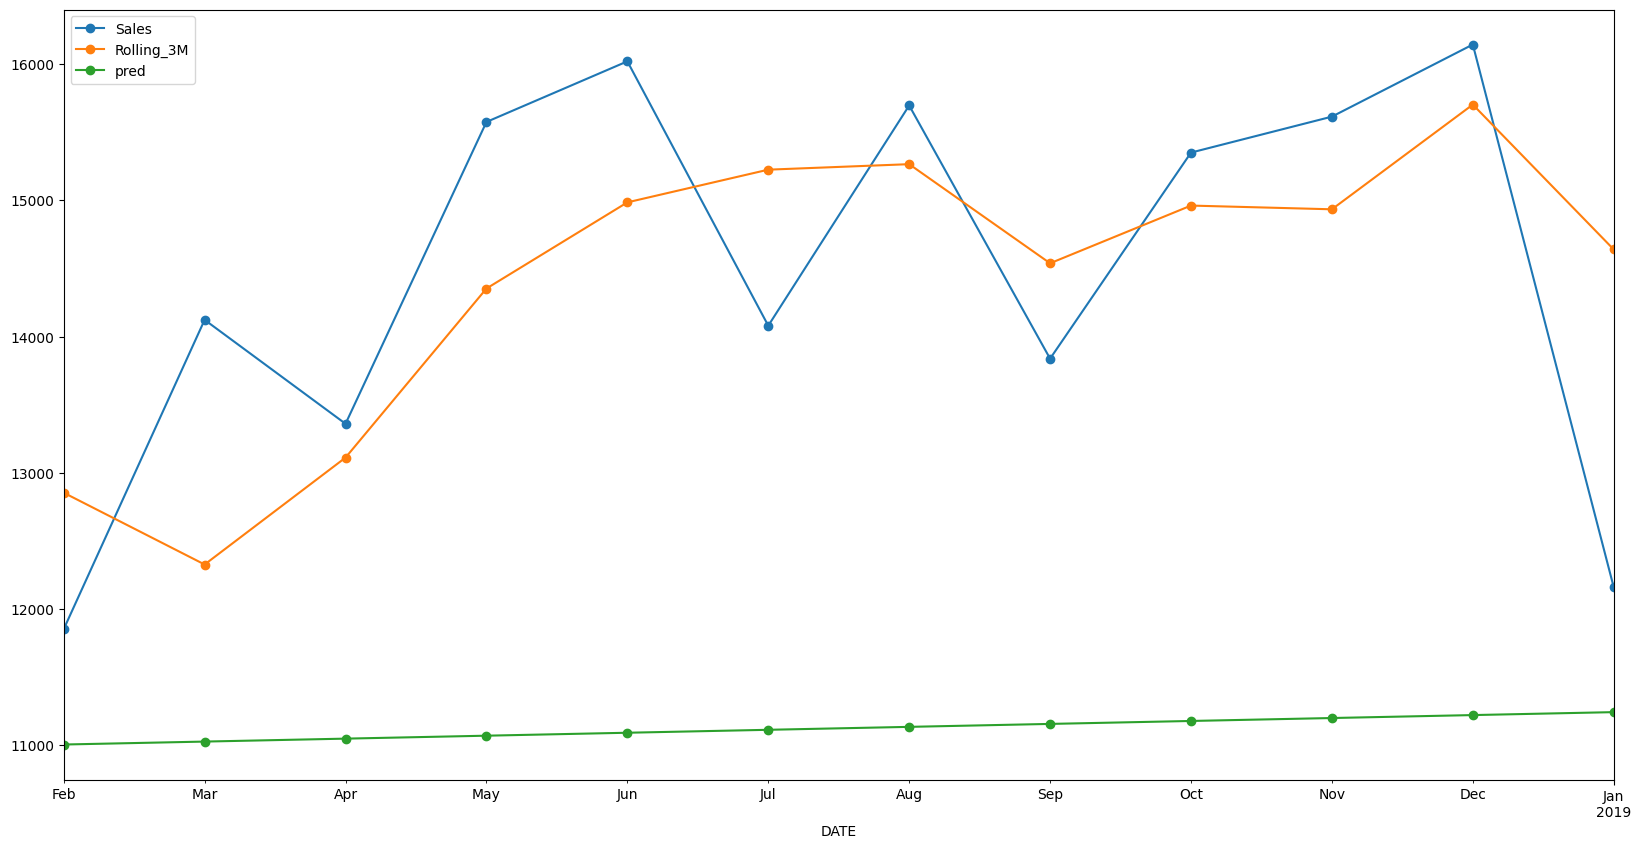

In [111]:
y_t = train_x['Sales'].iloc[-1]
y_0 = train_x['Sales'].iloc[0]

m = (y_t - y_0) / len(train_x['Sales'])
h = np.linspace(0, len(test_x)-1, len(test_x))

test_x['pred'] = y_t + m * h

test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])


### Moving Avg

In [112]:
pred_ = train_x.Sales.dropna().copy().values

for i in range(12):
    pred_ = np.append(pred_, pred_[-3:].mean())

In [113]:
pd.Series(pred_)

0       6573.360000
1       6654.000000
2       7332.000000
3       7332.000000
4       8240.000000
           ...     
212    13184.042219
213    13175.059036
214    13195.613236
215    13184.904830
216    13185.192368
Length: 217, dtype: float64

In [114]:
historical_sales = train_x['Sales'].dropna().values

# Initialize the prediction array with historical data
pred_ = historical_sales.copy()

# Number of future periods to forecast
n_forecast = 12

# Generate forecasts using a loop, appending the mean of the last 3 values each time
for _ in range(n_forecast):
    # Calculate the mean of the last 3 values in the current series
    last_three_mean = np.mean(pred_[-3:])
    # Append the new forecast value
    pred_ = np.append(pred_, last_three_mean)

# Optional: The first len(historical_sales) elements are historical,
# the last n_forecast are the predictions
print(f"Historical length: {len(historical_sales)}")
print(f"Total length after forecasting: {len(pred_)}")
print(f"Forecasted values: {pred_[-n_forecast:]}")

Historical length: 205
Total length after forecasting: 217
Forecasted values: [13802.33333333 13503.77777778 12770.37037037 13358.82716049
 13210.99176955 13113.39643347 13227.7384545  13184.04221917
 13175.05903572 13195.61323646 13184.90483045 13185.19236754]


In [115]:
test_x['pred'] = pred_[-12:]

MAE : 1738.024
RMSE : 1940.885
MAPE: 0.117


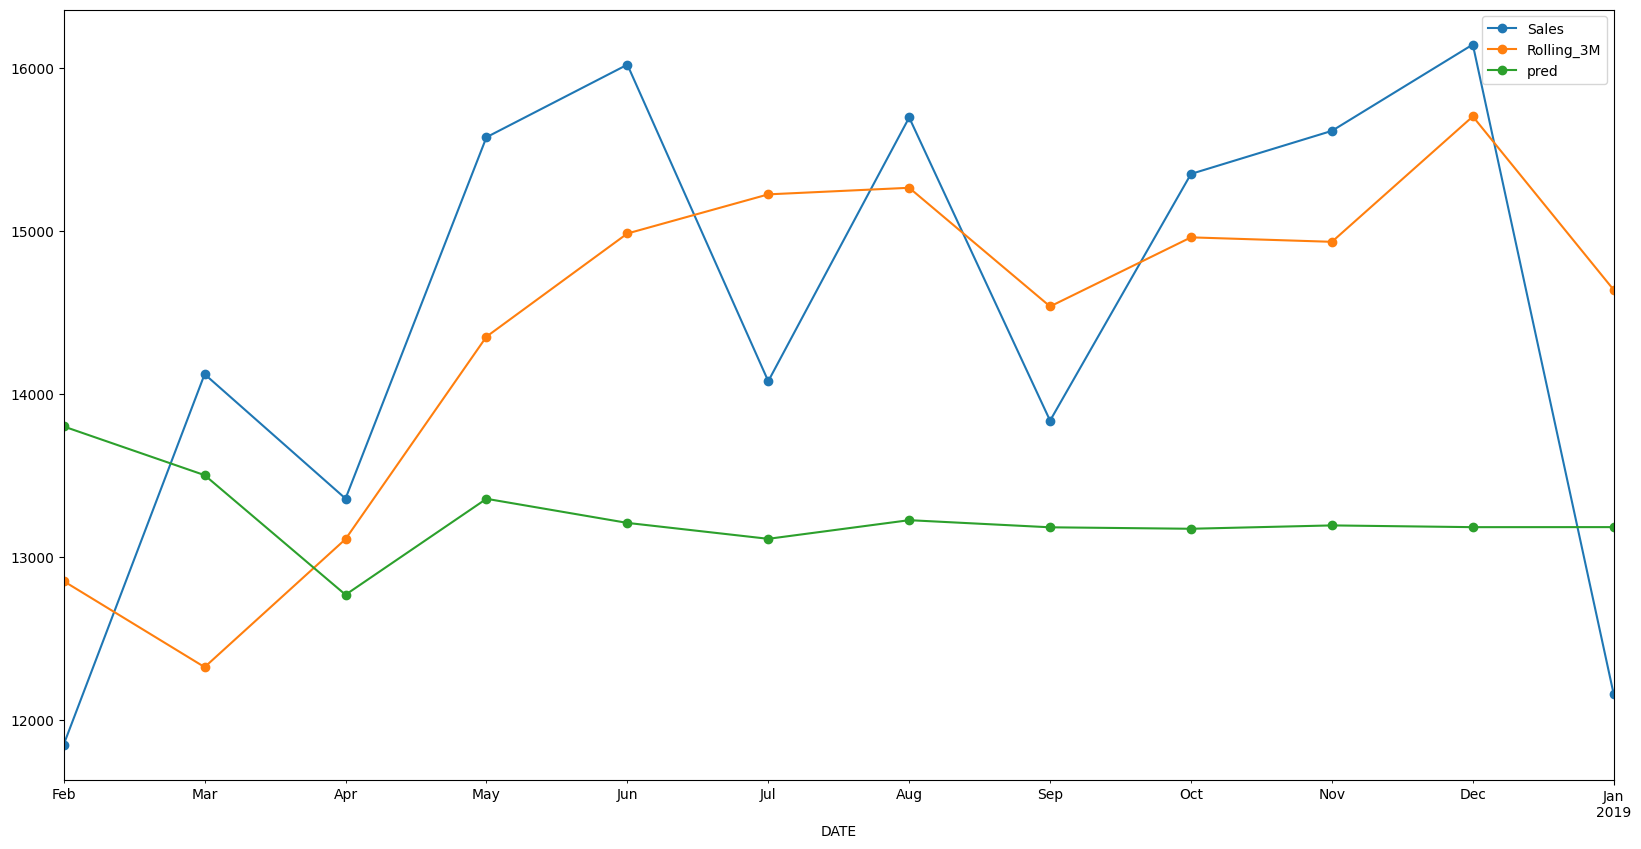

In [116]:
test_x.plot(style='-o')

performance(test_x['Sales'], test_x['pred'])

#### Smoothing Methods

In [117]:
# model = sm.tsa.SimpleExpSmoothing(mobile_sales.Sales)
# _ = model.fit(smoothing_level = 0.8)
# _.fittedvalues


import pandas as pd
import statsmodels.api as sm
import numpy as np
# Fit Simple Exponential Smoothing model with smoothing level (alpha) = 0.8
model = sm.tsa.SimpleExpSmoothing(mobile_sales['Sales'])  # Use column access for clarity
fitted_model = model.fit(smoothing_level=0.8)  # Assign to a descriptive variable instead of '_'

# Extract fitted values (in-sample one-step-ahead predictions)
fitted_values = fitted_model.fittedvalues

# Display or return the fitted values
print(fitted_values)



DATE
2001-01-01     6573.360000
2001-02-01     6573.360000
2001-03-01     6637.872000
2001-04-01     7193.174400
2001-05-01     7304.234880
                  ...     
2018-09-01    15444.233816
2018-10-01    14159.246763
2018-11-01    15112.649353
2018-12-01    15514.529871
2019-01-01    16018.489974
Length: 217, dtype: float64


d:\Lens\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Lens\.venv\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


In [118]:
# Optional: For forecasting future periods (e.g., next 12 months)
forecast_steps = 12
forecast = fitted_model.forecast(steps=forecast_steps)
print("Forecasted values:", forecast)

Forecasted values: 2019-02-01    12931.697995
2019-03-01    12931.697995
2019-04-01    12931.697995
2019-05-01    12931.697995
2019-06-01    12931.697995
2019-07-01    12931.697995
2019-08-01    12931.697995
2019-09-01    12931.697995
2019-10-01    12931.697995
2019-11-01    12931.697995
2019-12-01    12931.697995
2020-01-01    12931.697995
Freq: MS, dtype: float64


### Moving Avg

d:\Lens\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Lens\.venv\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


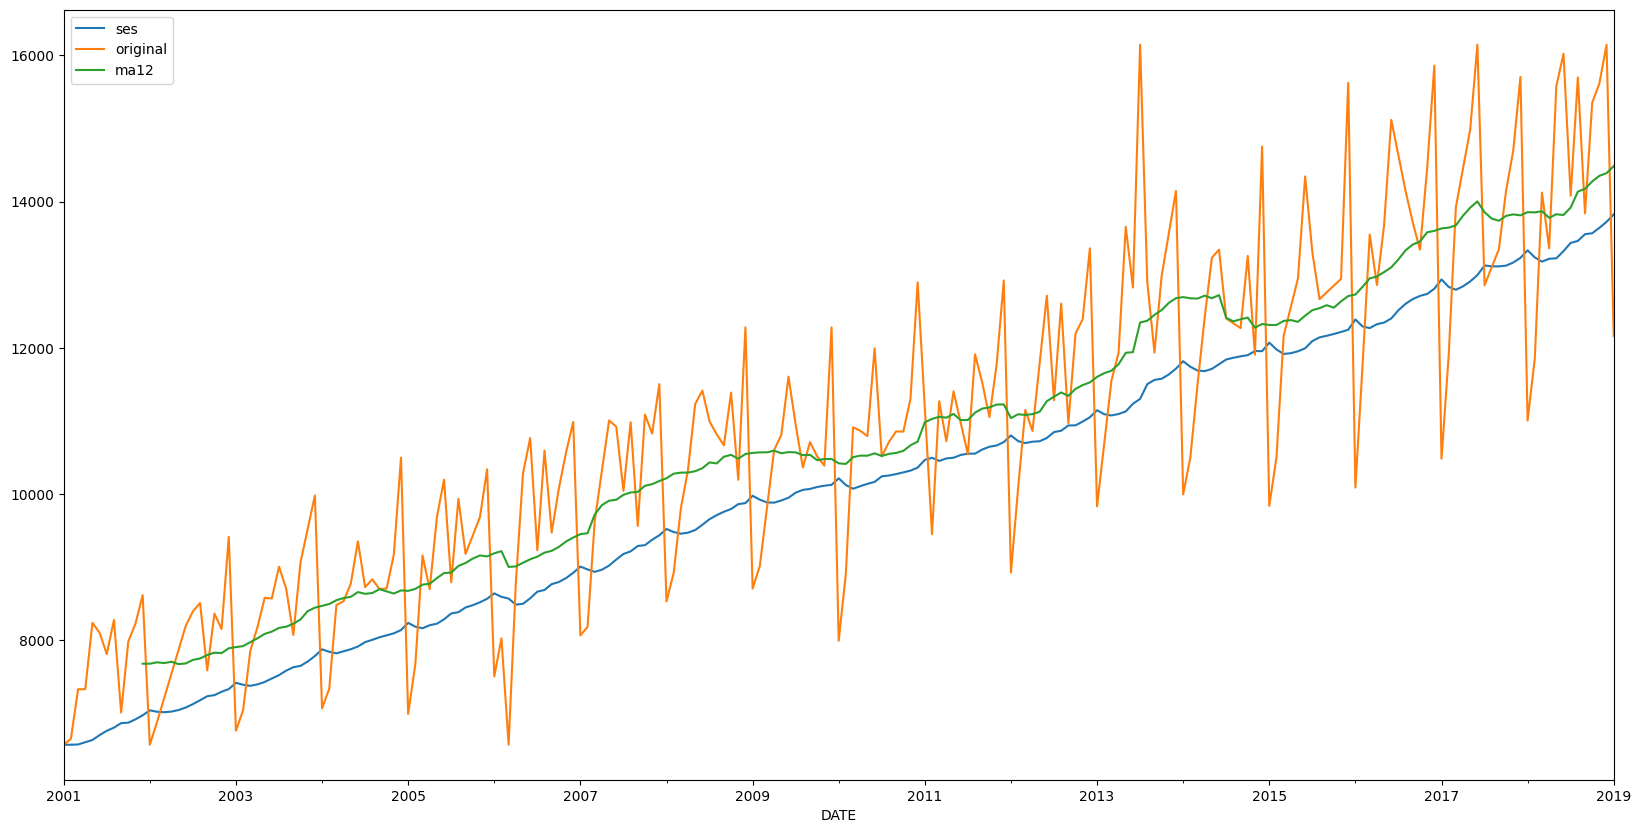

In [119]:
pred = pd.Series(sm.tsa.SimpleExpSmoothing(mobile_sales.Sales).fit(smoothing_level=1/(2*12)).fittedvalues)

pred.plot(label='ses')
mobile_sales.Sales.plot(label='original')
mobile_sales.Sales.rolling(12).mean().plot(label='ma12')
plt.legend()

d:\Lens\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Lens\.venv\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


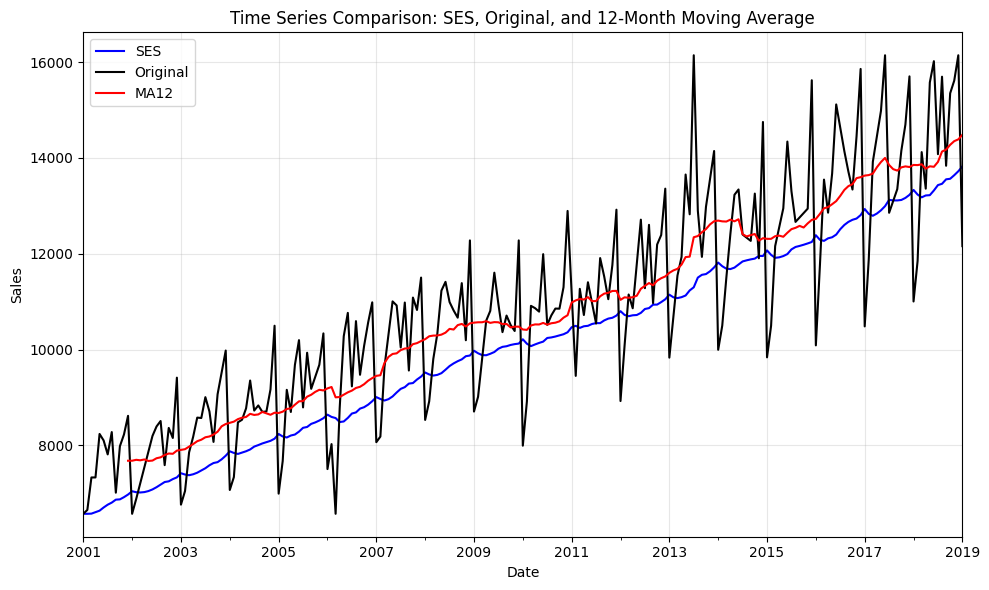

Model Summary:
                       SimpleExpSmoothing Model Results                       
Dep. Variable:                  Sales   No. Observations:                  217
Model:             SimpleExpSmoothing   SSE                      425671036.423
Optimized:                      False   AIC                           3148.174
Trend:                           None   BIC                           3154.934
Seasonal:                        None   AICC                          3148.362
Seasonal Periods:                None   Date:                 Mon, 08 Sep 2025
Box-Cox:                        False   Time:                         12:03:18
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.0416667                alpha                False
initial_level              6573.3600 

In [120]:
# Calculate smoothing level (alpha) = 1 / (2 * 12) for a 24-period equivalent smoothing
smoothing_level = 1 / (2 * 12)

# Fit Simple Exponential Smoothing model
model = sm.tsa.SimpleExpSmoothing(mobile_sales['Sales'])  # Explicit column access
fitted_model = model.fit(smoothing_level=smoothing_level)  # Assign to variable for reusability

# Extract fitted values as a pandas Series (aligned with the original index)
pred = pd.Series(fitted_model.fittedvalues, index=mobile_sales.index)

# Create the plot
plt.figure(figsize=(10, 6))  # Set figure size for better visibility
pred.plot(label='SES', color='blue')  # SES for Simple Exponential Smoothing
mobile_sales['Sales'].plot(label='Original', color='black')  # Explicit column and color
mobile_sales['Sales'].rolling(window=12).mean().plot(label='MA12', color='red')  # 12-period moving average
plt.title('Time Series Comparison: SES, Original, and 12-Month Moving Average')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha=0.3)  # Add grid for readability
plt.tight_layout()  # Adjust layout to prevent label cutoff
plt.show()  # Display the plot (or save with plt.savefig('plot.png') if needed)

# Optional: Print summary statistics for verification
print("Model Summary:")
print(fitted_model.summary())
print(f"\nFitted Values Shape: {pred.shape}")
print(f"Original Sales Shape: {mobile_sales['Sales'].shape}")

d:\Lens\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Lens\.venv\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


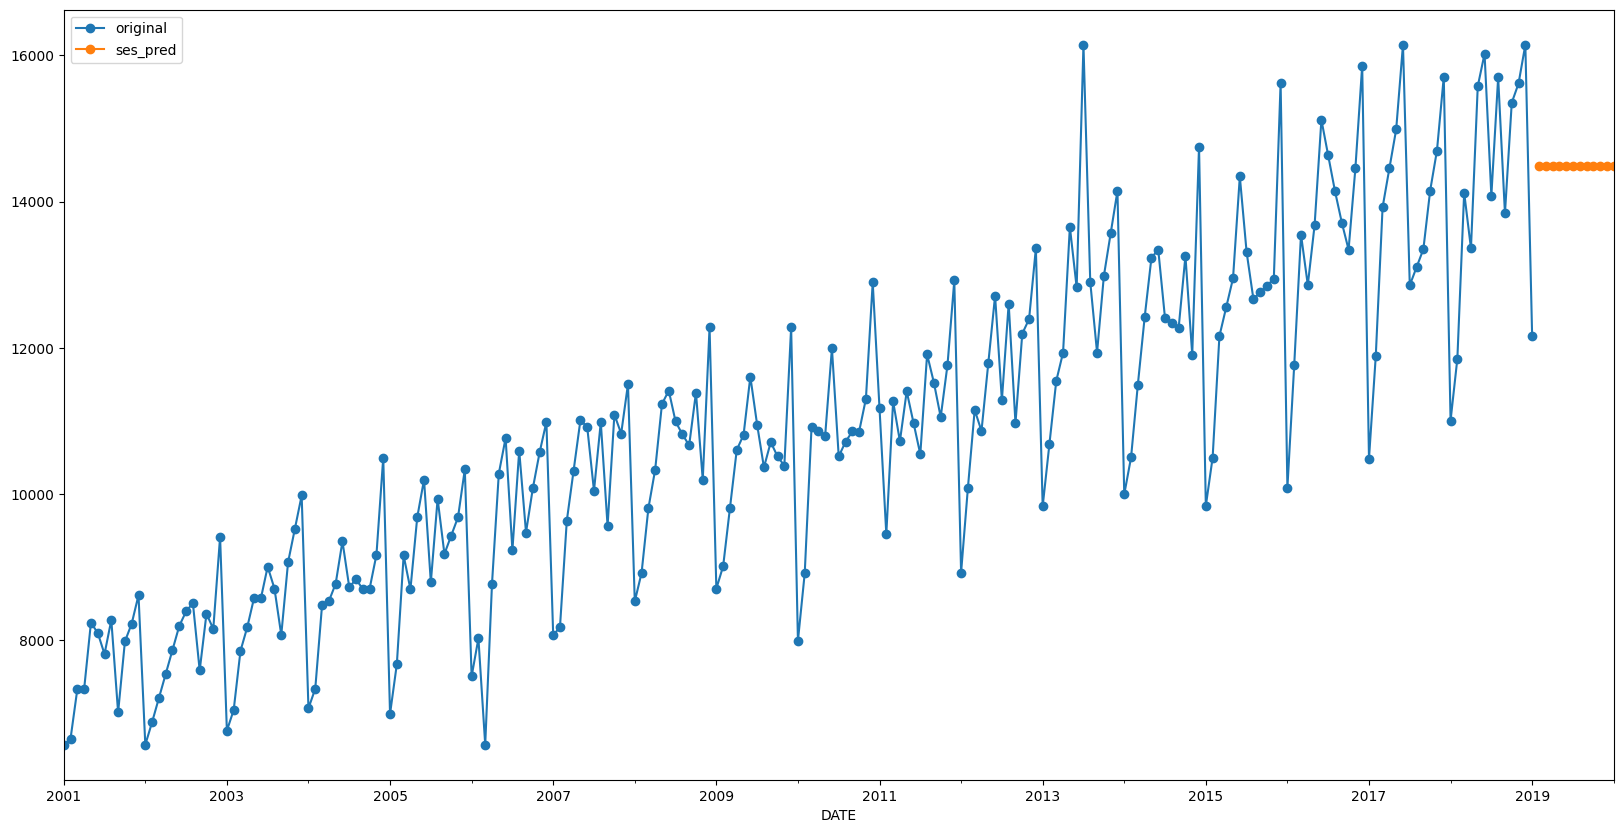

In [124]:
model = sm.tsa.SimpleExpSmoothing(mobile_sales.Sales).fit(smoothing_level=0.2)
pred = model.forecast(12)

mobile_sales.Sales.plot(label='original', style='-o')
pred.plot(label='ses_pred', style='-o')
plt.legend()

d:\Lens\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Lens\.venv\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


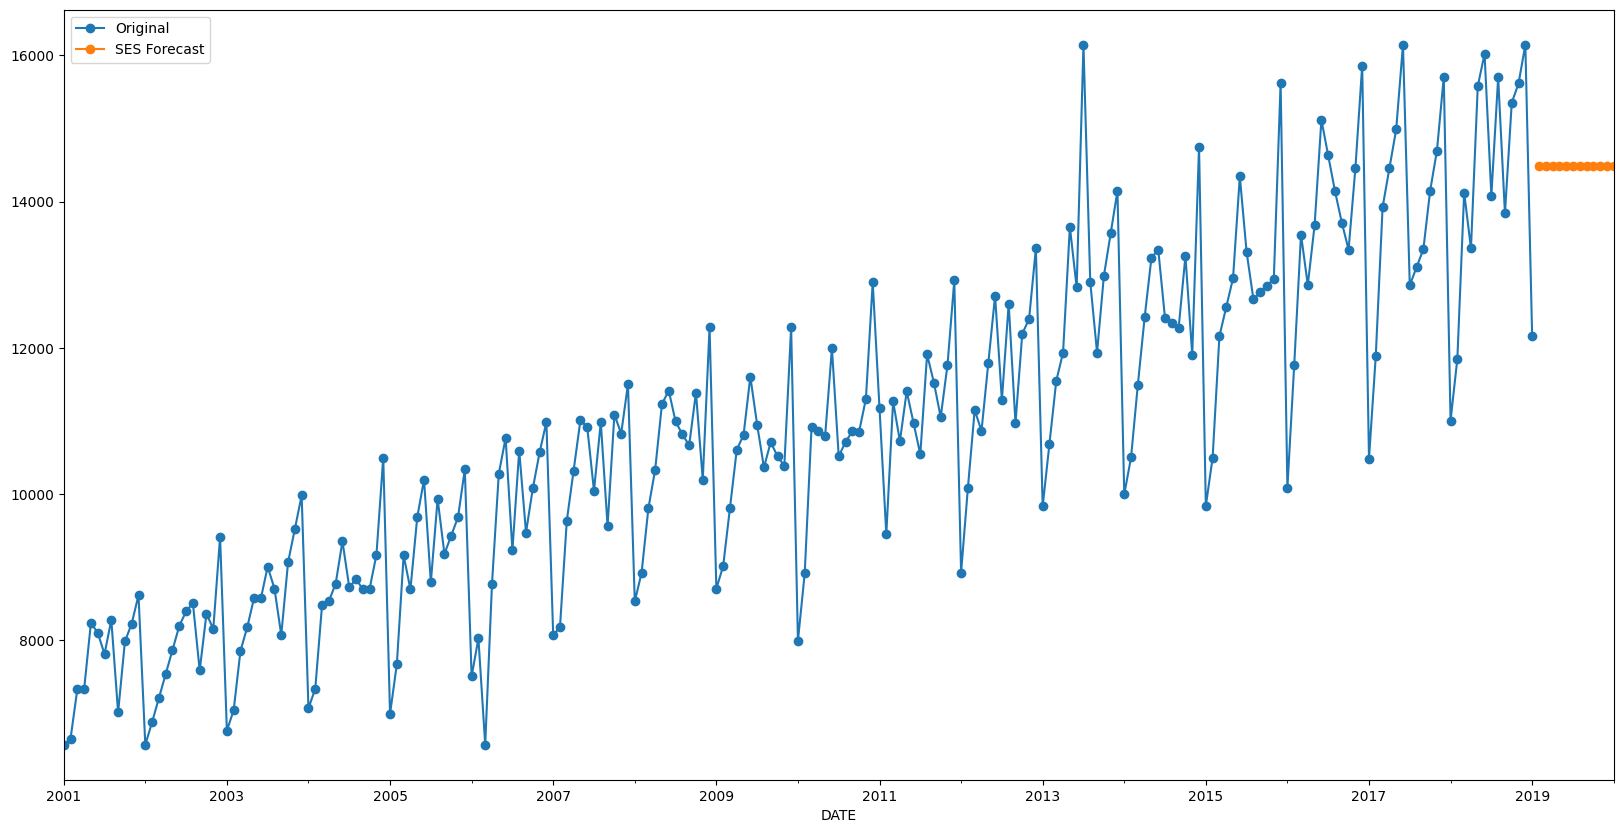

In [125]:
model = sm.tsa.SimpleExpSmoothing(mobile_sales['Sales']).fit(smoothing_level=0.2)

# Generate 12-step forecast
pred = model.forecast(12)

# Create the plot
mobile_sales['Sales'].plot(label='Original', style='-o')
pred.plot(label='SES Forecast', style='-o')
plt.legend()
plt.show()

In [126]:
_ = sm.tsa.ExponentialSmoothing(mobile_sales.Sales, trend='add')

d:\Lens\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [127]:
_.fit()

d:\Lens\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


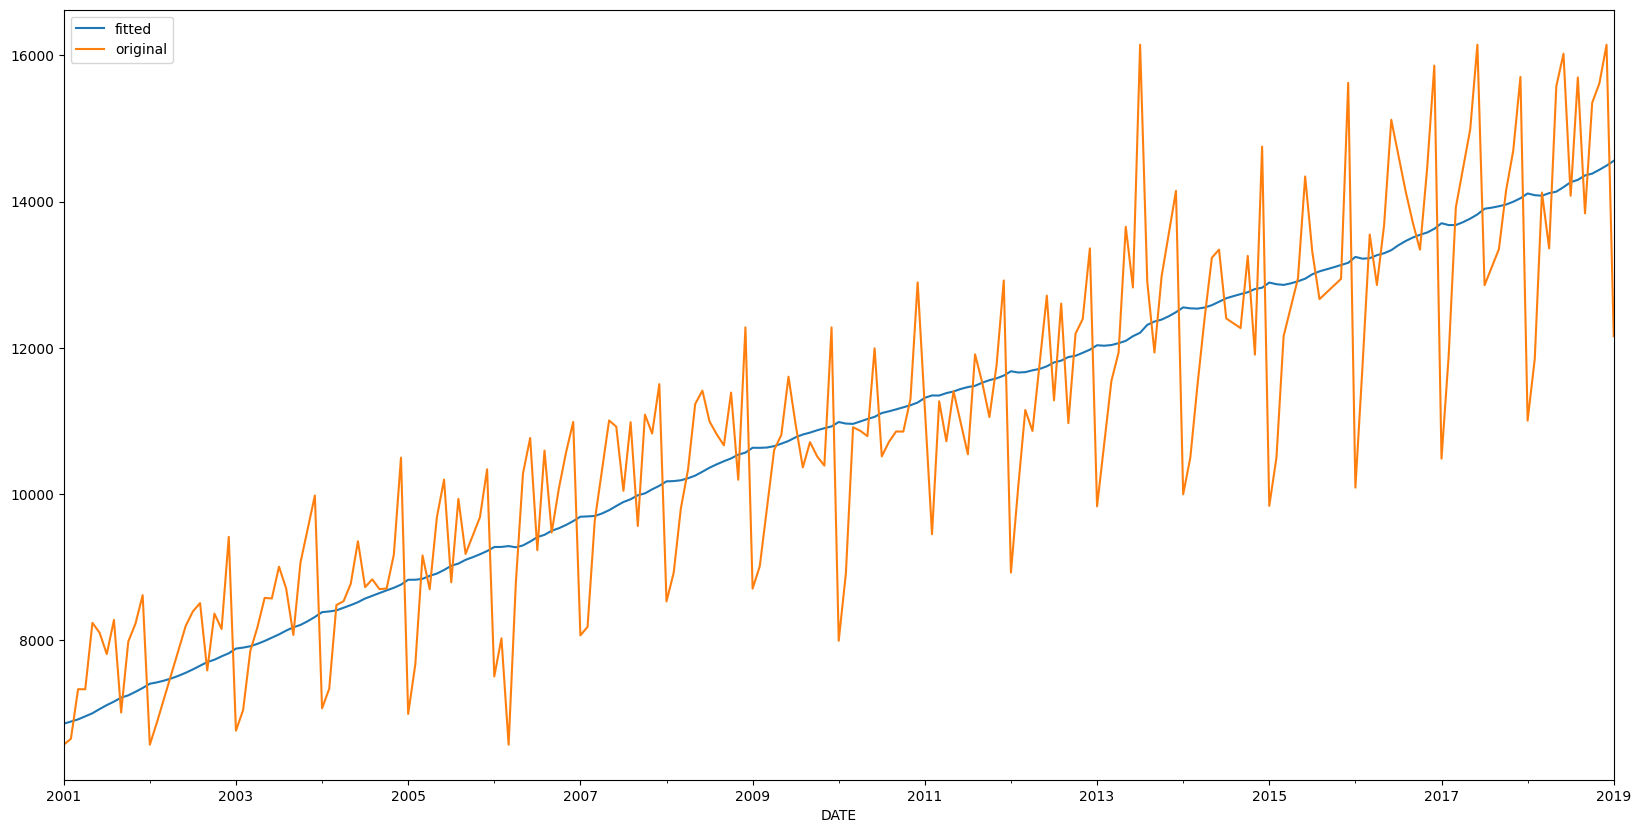

In [128]:
model = sm.tsa.ExponentialSmoothing(mobile_sales.Sales, trend='add').fit()
model.fittedvalues.plot(label='fitted')
mobile_sales.Sales.plot(label='original')
plt.legend()

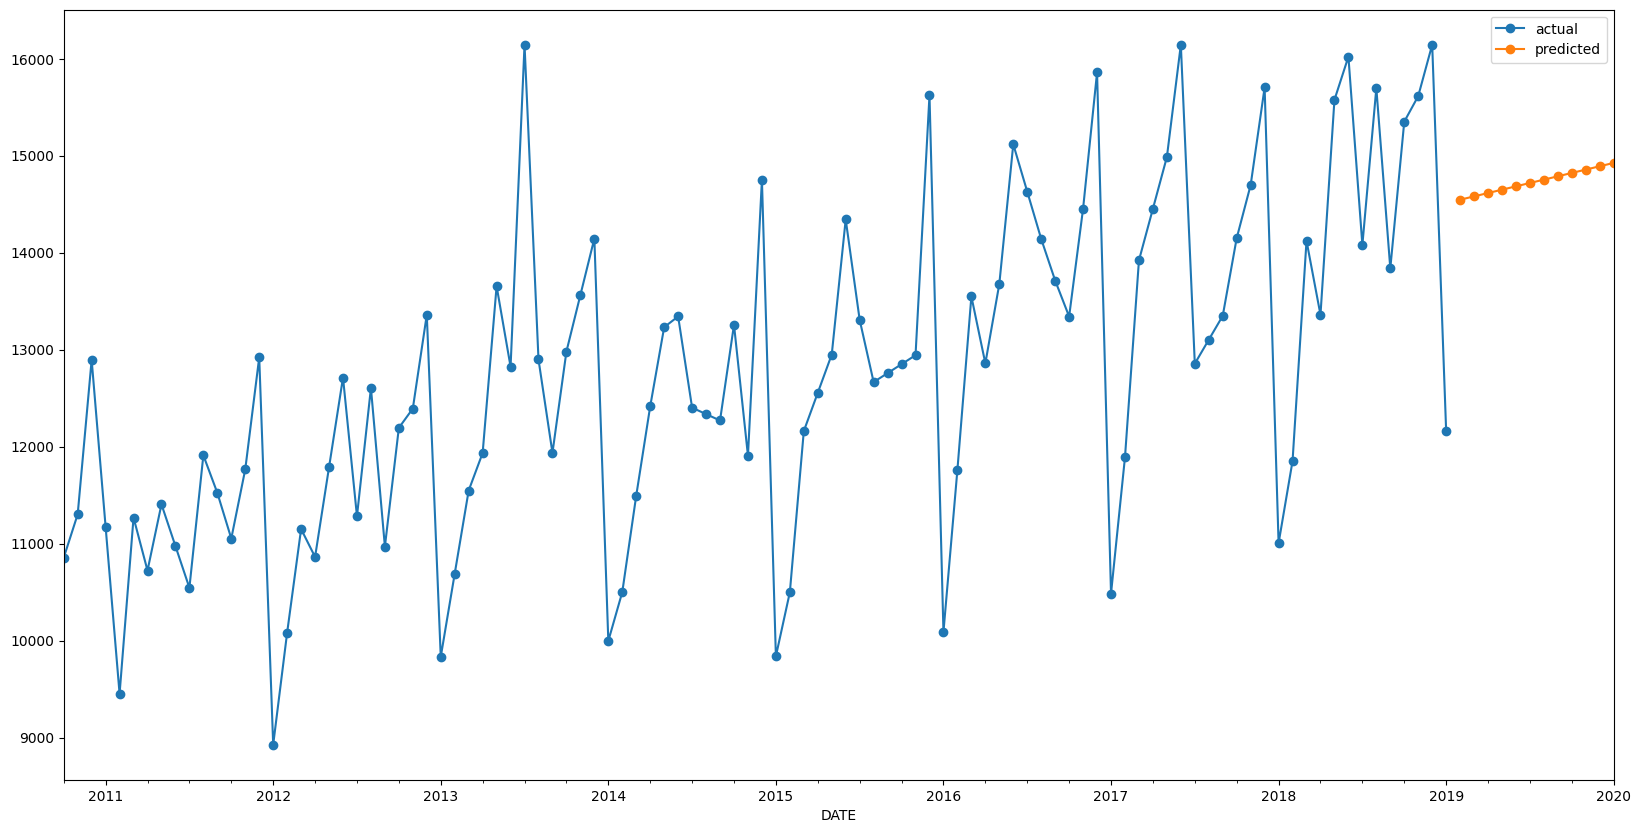

In [130]:
pred = model.forecast(steps = 12)
mobile_sales.Sales.tail(100).plot(style='-o', label='actual')
pred.plot(style='-o', label='predicted')
plt.legend()

d:\Lens\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


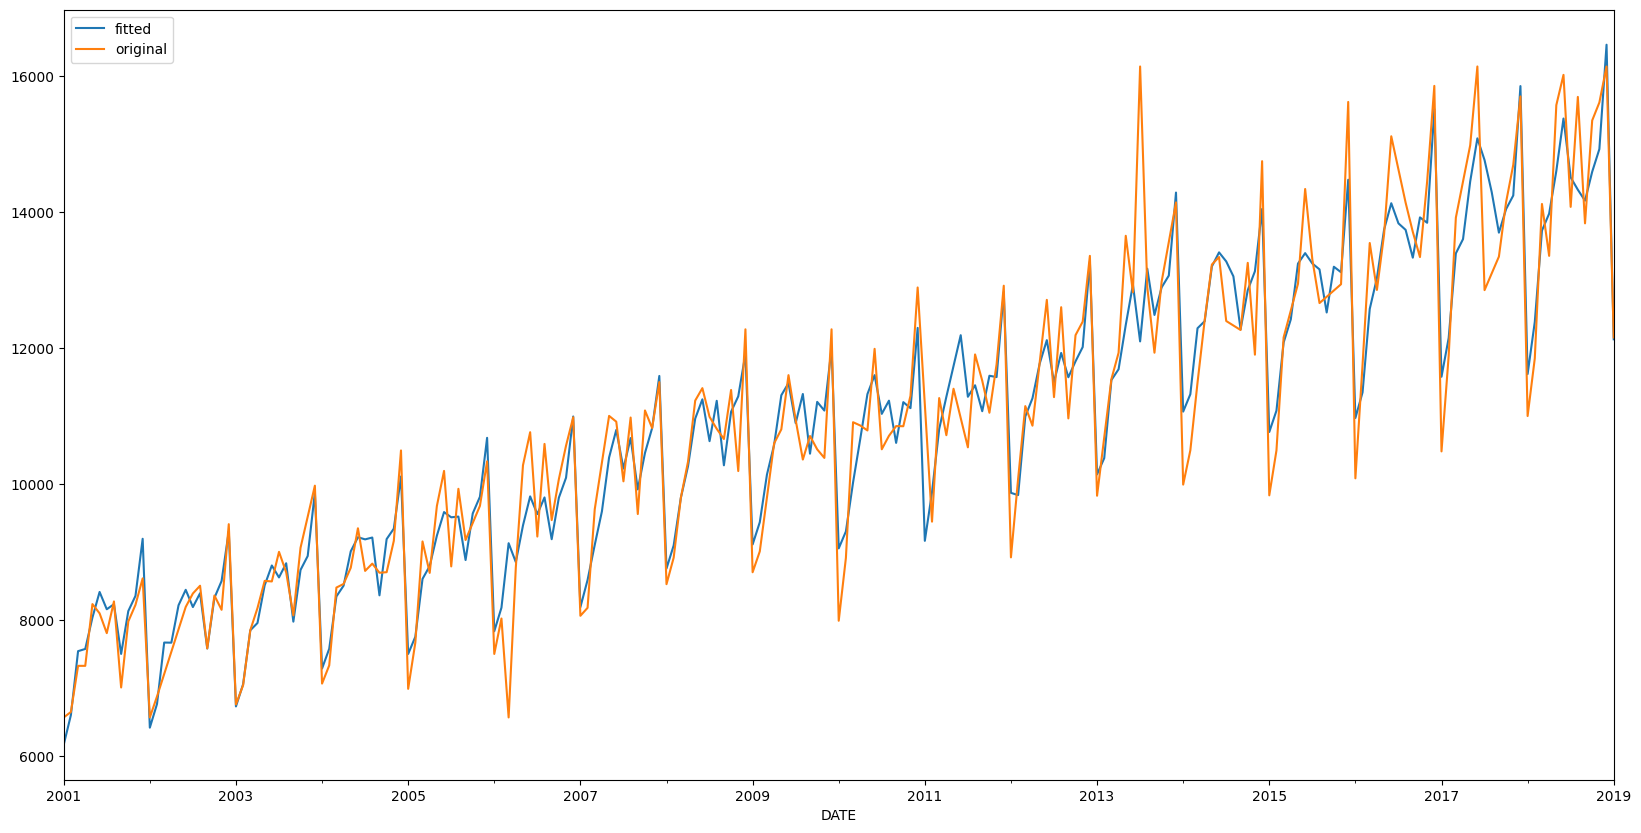

In [131]:
model = sm.tsa.ExponentialSmoothing(mobile_sales.Sales, trend='add', seasonal='add').fit()
model.fittedvalues.plot(label='fitted')
mobile_sales.Sales.plot(label='original')
plt.legend()

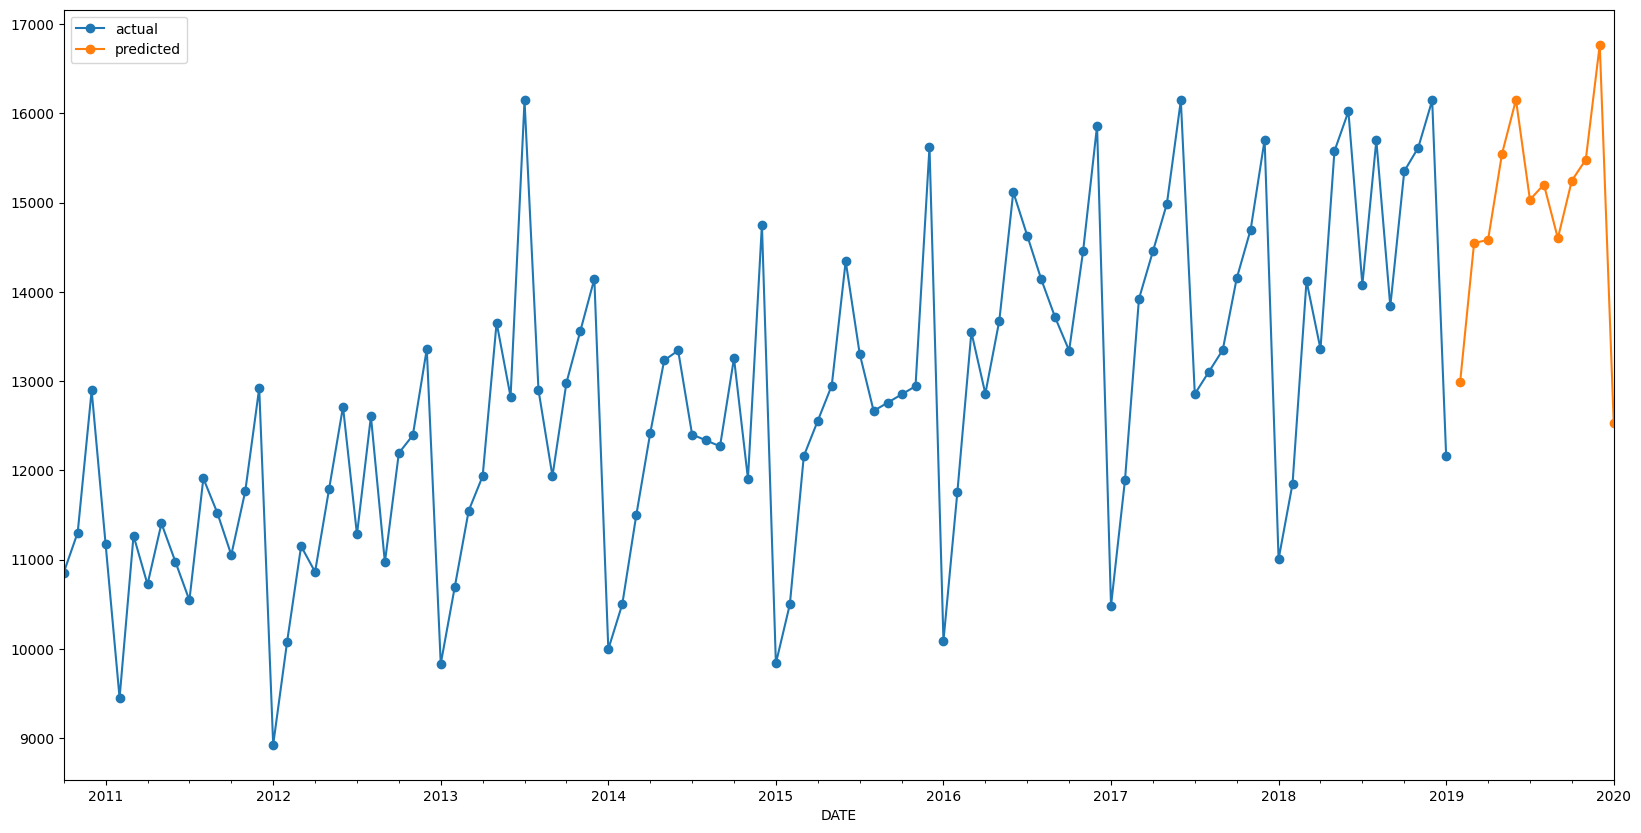

In [132]:
pred = model.forecast(steps = 12)
mobile_sales.Sales.tail(100).plot(style='-o', label='actual')
pred.plot(style='-o', label='predicted')
plt.legend()

d:\Lens\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


MAE : 530.883
RMSE : 558.05
MAPE: 0.036


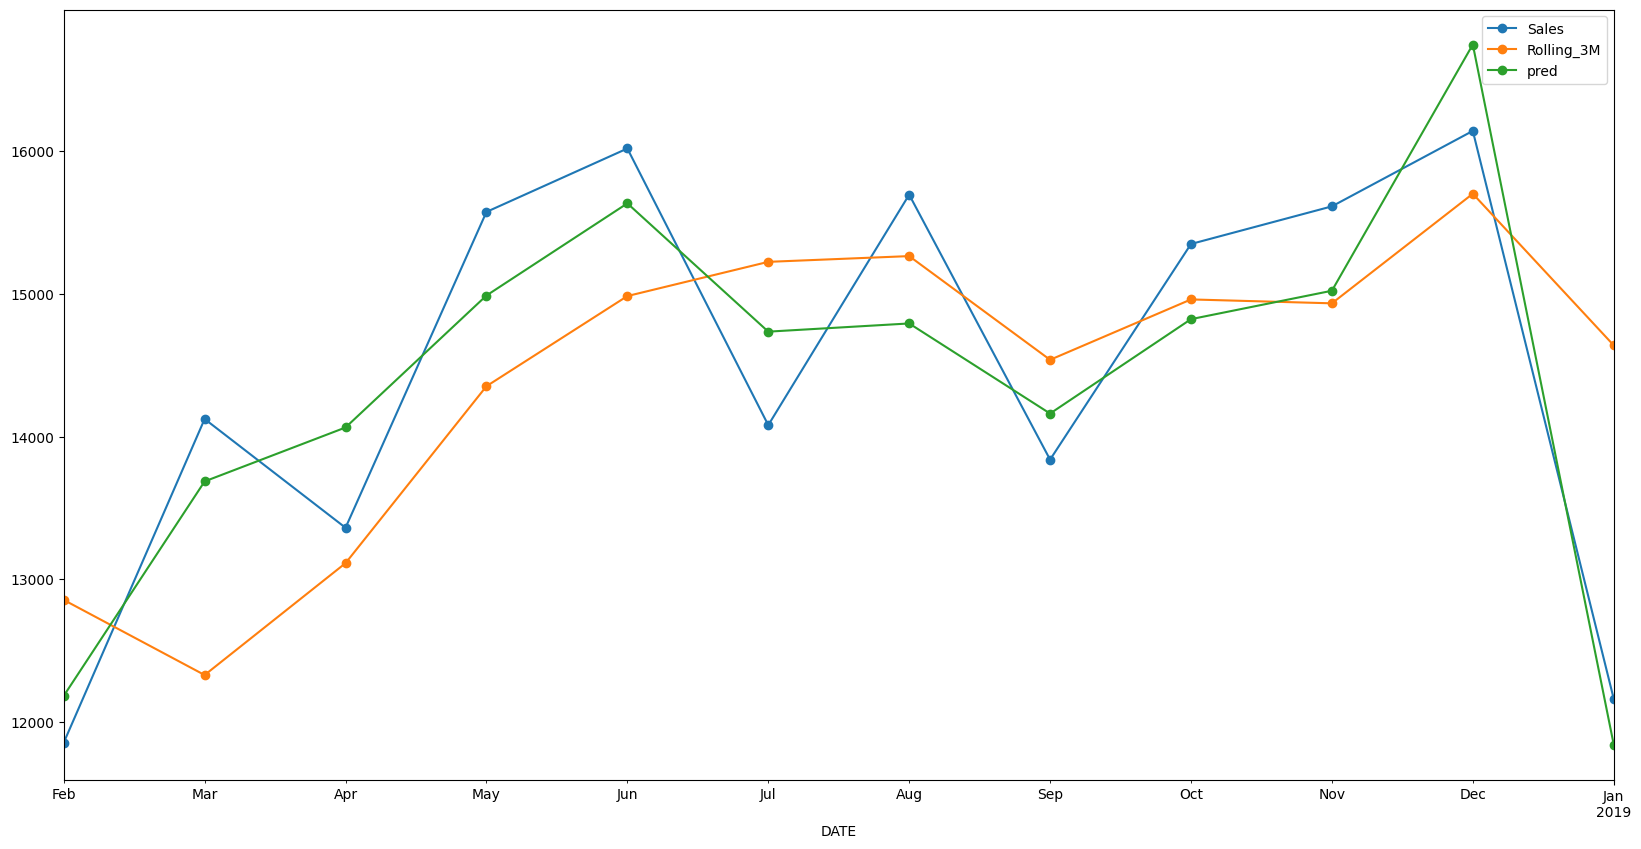

In [133]:
model = sm.tsa.ExponentialSmoothing(train_x.Sales, trend='mul', seasonal='mul').fit(smoothing_level=1/(2*12))
test_x['pred'] = model.forecast(steps=12)
test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

<Axes: xlabel='DATE'>

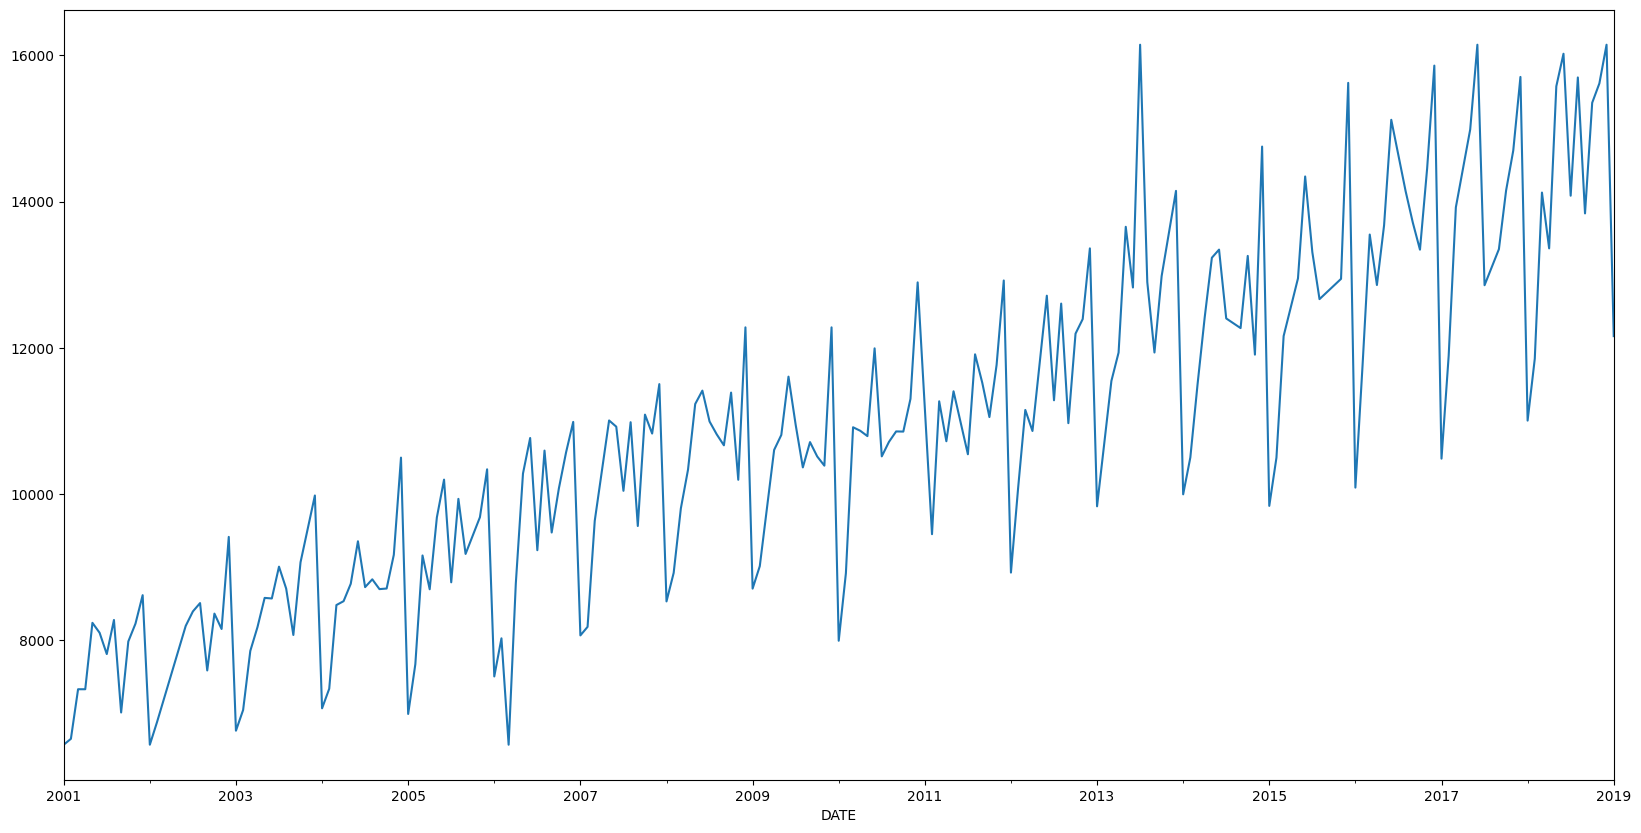

In [134]:
mobile_sales.Sales.plot()

### Dickey-Fuller test

In [135]:
sm.tsa.stattools.adfuller(mobile_sales.Sales)[1]

np.float64(0.9786335779042277)

In [137]:
def adf_test(data, significance_level=0.05):
    pvalue = sm.tsa.stattools.adfuller(data)[1] 
    if pvalue <= significance_level:
        print('Sequence is stationary')
    else:
        print('Sequence is not stationary')

adf_test(mobile_sales.Sales)

Sequence is not stationary


In [138]:
import statsmodels.api as sm

model = sm.tsa.seasonal_decompose(mobile_sales.Sales, model='additive')

<Axes: xlabel='DATE'>

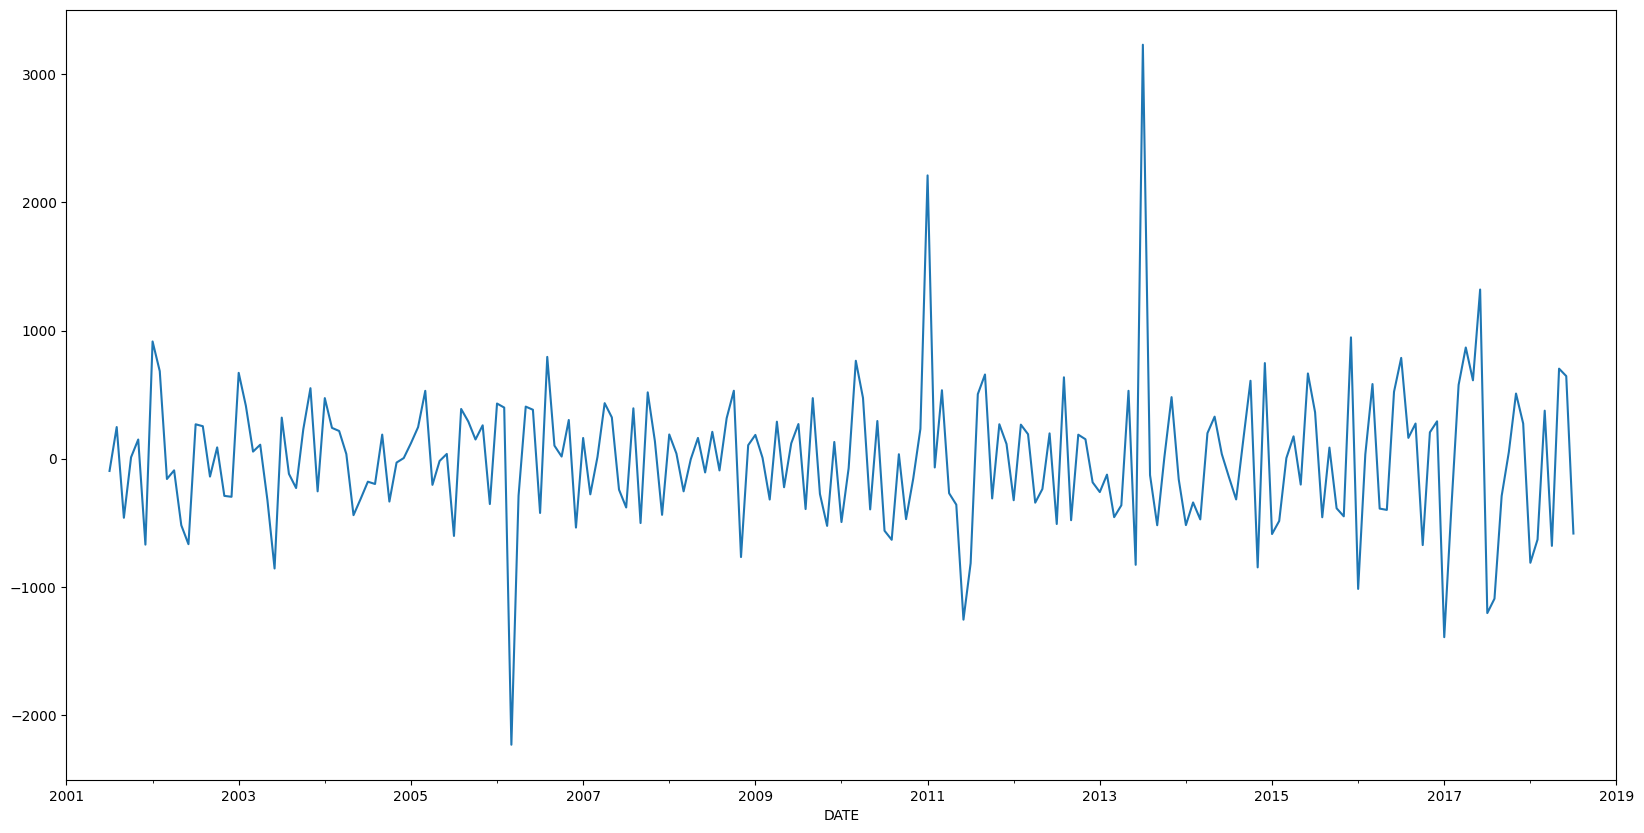

In [139]:
model.resid.plot()

In [140]:
adf_test(model.resid.dropna())

Sequence is stationary


<Axes: xlabel='DATE'>

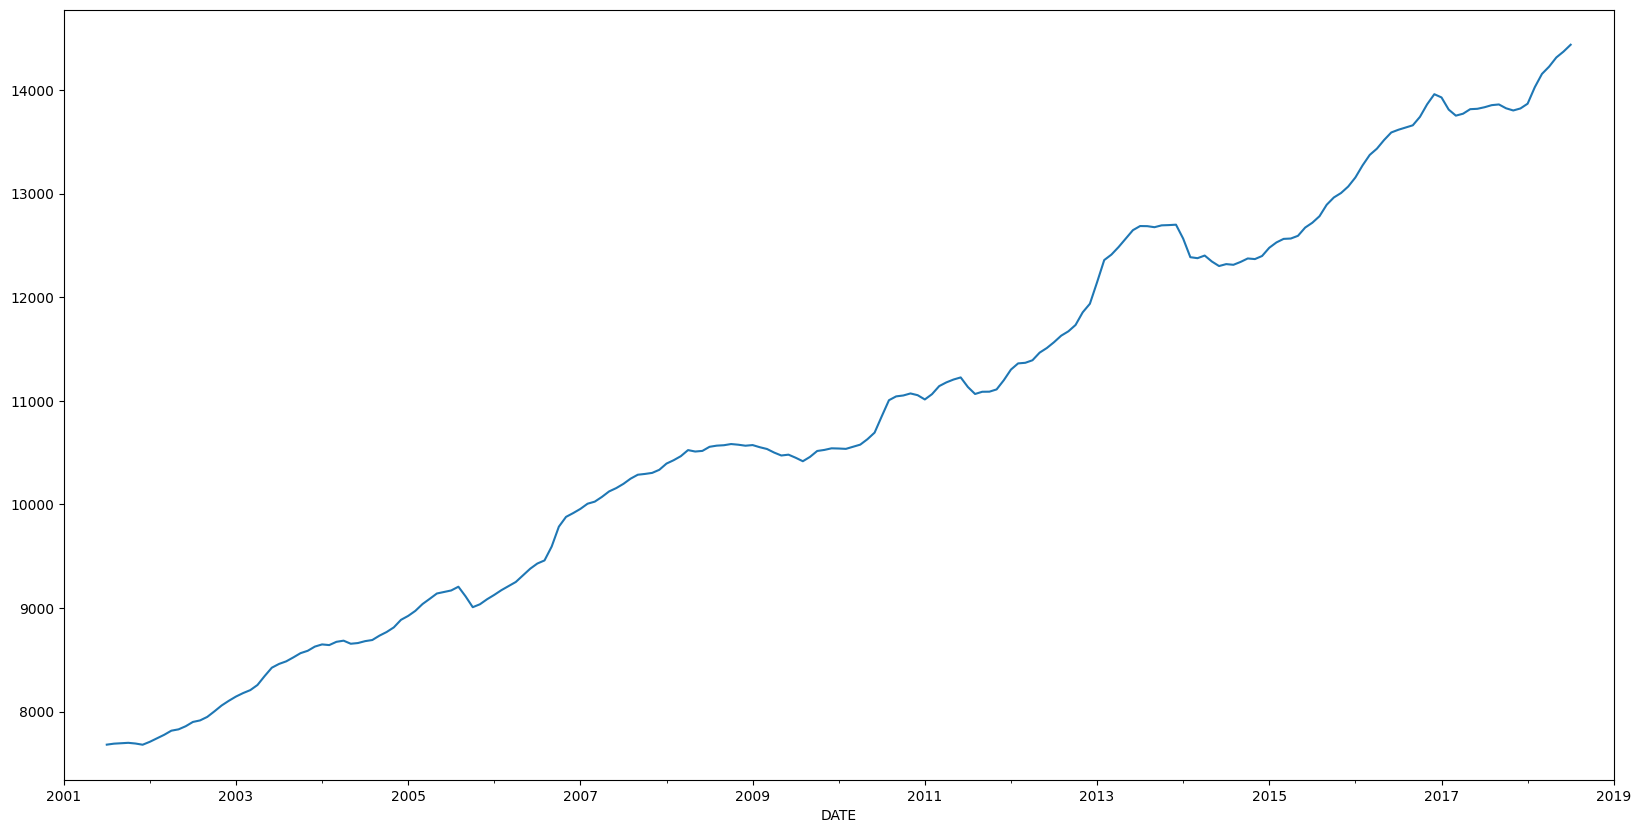

In [141]:
model.trend.plot()

<Axes: xlabel='DATE'>

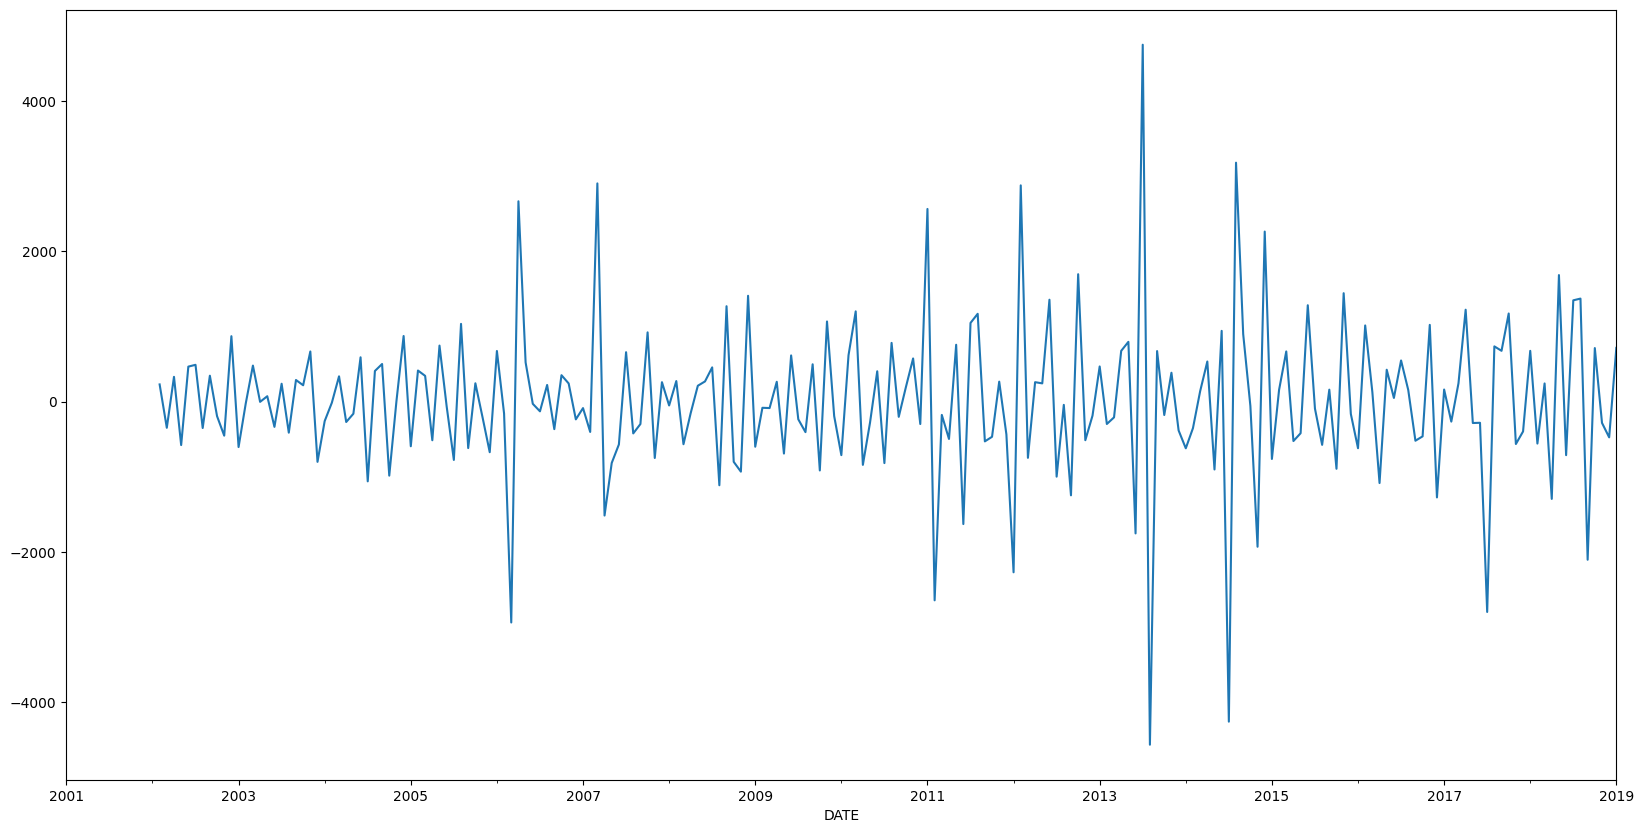

In [142]:
mobile_sales.Sales.diff(12).diff(1).plot()

In [143]:
adf_test(mobile_sales.Sales.diff(12).diff(1).dropna())

Sequence is stationary


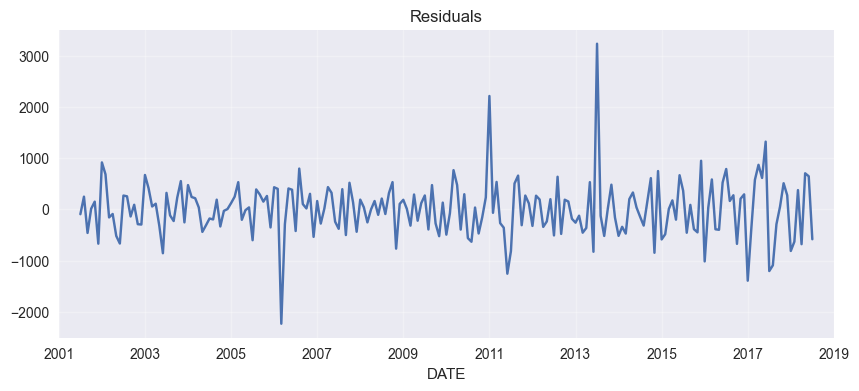

Sequence is stationary


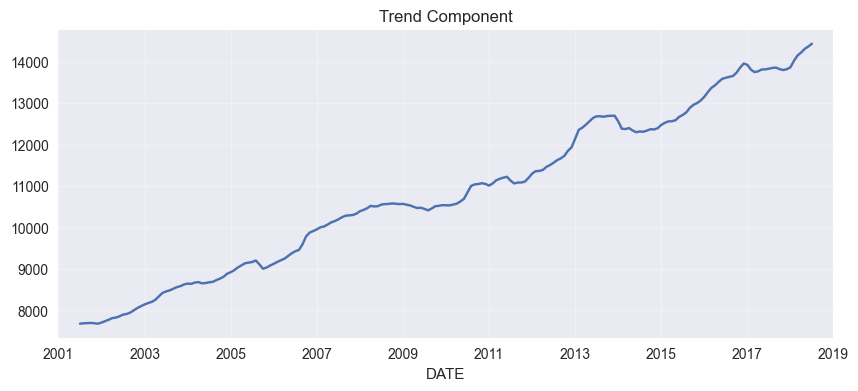

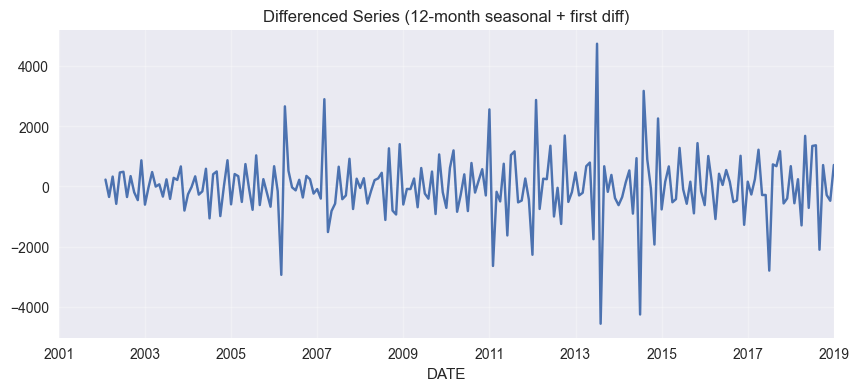

Sequence is stationary


In [145]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# 1. Seasonal decomposition (additive)
decomposition = sm.tsa.seasonal_decompose(mobile_sales.Sales, model='additive')

# 2. Plot residuals
plt.figure(figsize=(10,4))
decomposition.resid.plot(title='Residuals')
plt.show()

# 3. Check stationarity of residuals
adf_test(decomposition.resid.dropna())

# 4. Plot trend component
plt.figure(figsize=(10,4))
decomposition.trend.plot(title='Trend Component')
plt.show()

# 5. Seasonal differencing: Remove yearly seasonality (lag=12 for monthly data) and first difference
diff_series = mobile_sales.Sales.diff(12).diff(1)
plt.figure(figsize=(10,4))
diff_series.plot(title='Differenced Series (12-month seasonal + first diff)')
plt.show()

# 6. Check stationarity of differenced series
adf_test(diff_series.dropna())


In [158]:
mobile_sales.Sales

DATE
2001-01-01    6573.36
2001-02-01    6654.00
2001-03-01    7332.00
2001-04-01    7332.00
2001-05-01    8240.00
2001-06-01    8104.00
2001-07-01    7813.00
2001-08-01    8279.00
2001-09-01    7014.00
2001-10-01    7985.00
Name: Sales, dtype: float64

In [146]:
np.corrcoef(mobile_sales.Sales[1:], mobile_sales.Sales.shift(1).dropna())[0][1]

np.float64(0.7974860661369779)

In [147]:
# Lag-1 autocorrelation
lag1_corr = mobile_sales.Sales.autocorr(lag=1)
print("Lag-1 autocorrelation:", lag1_corr)


Lag-1 autocorrelation: 0.7974860661369779


<StemContainer object of 3 artists>

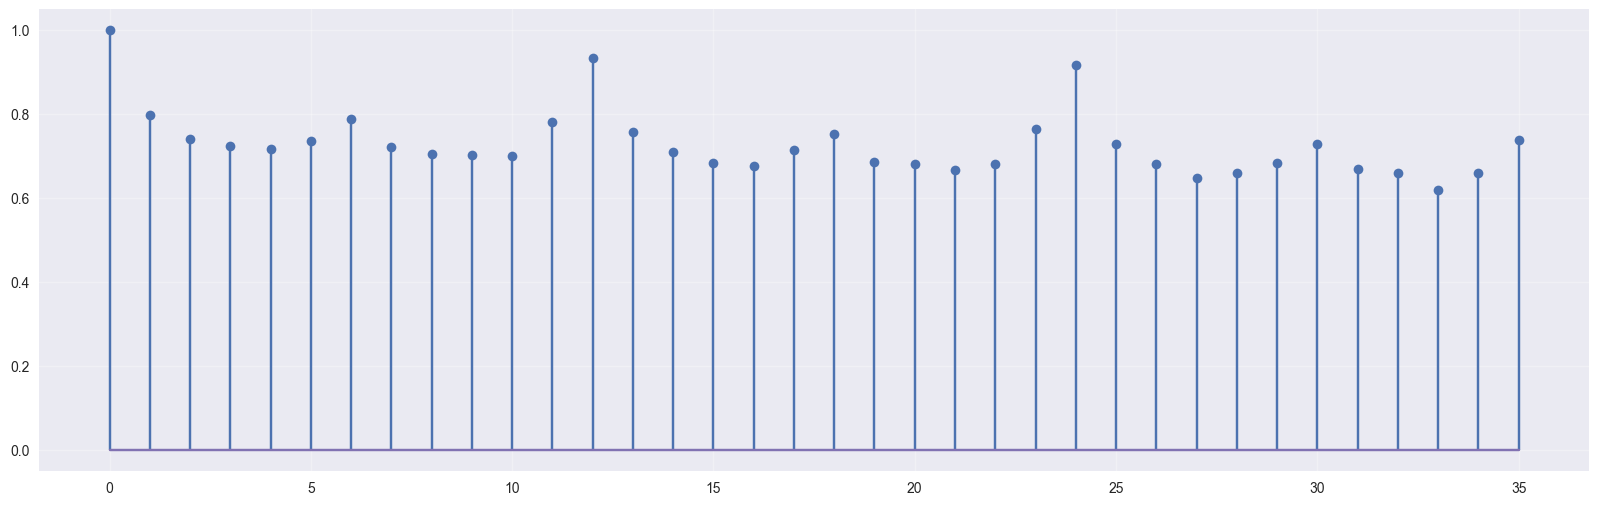

In [151]:
plt.figure(figsize=(20, 6))
corr = []
for lag in range(36):
    corr.append(np.corrcoef(mobile_sales.Sales[lag:], mobile_sales.Sales.shift(lag).dropna())[0][1])

plt.stem(np.arange(36), corr)

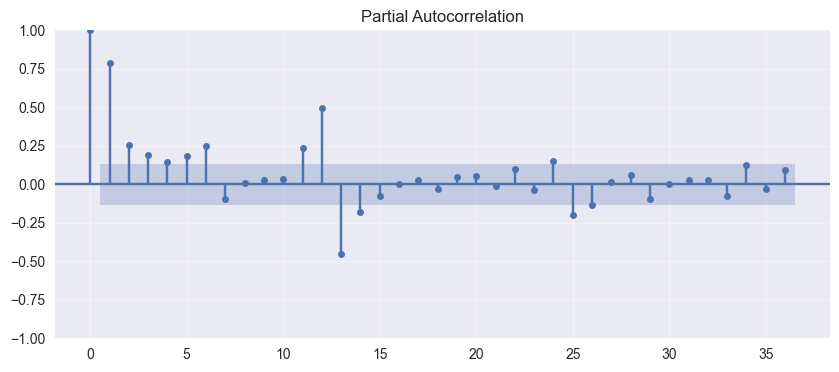

In [152]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 
plot_pacf(mobile_sales.Sales, lags=36);

 
### ARIMA FAMILY

In [153]:
train_x.head()

,Sales,Rolling_3M
DATE,,
2001-01-01,6573.36,NaN
2001-02-01,6654.00,NaN
2001-03-01,7332.00,6853.120000
2001-04-01,7332.00,7106.000000
2001-05-01,8240.00,7634.666667


In [154]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [156]:
train_x_st = train_x.copy()
train_x_st.Sales = train_x_st.Sales.diff(1)
train_x_st.dropna(inplace=True)
adf_test(train_x_st.Sales)

Sequence is stationary


### AR(p)

d:\Lens\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Lens\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Lens\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
d:\Lens\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


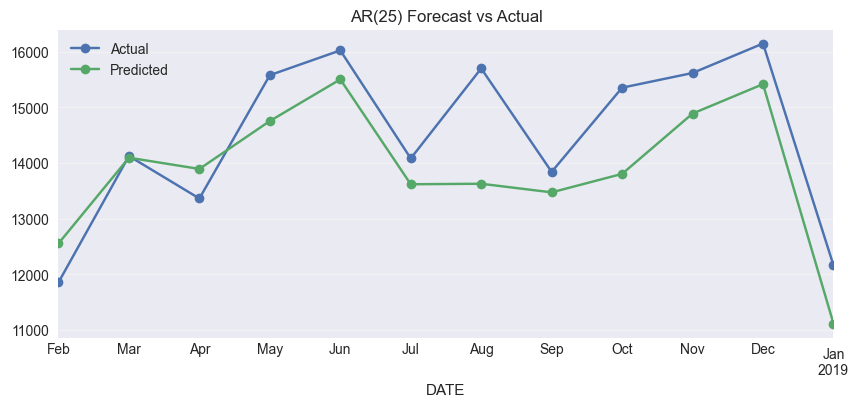

MAE : 796.989
RMSE : 954.188
MAPE: 0.055


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit AR(25) model on stationary training data
sarimax_model = SARIMAX(train_x_st['Sales'], order=(25, 0, 0))
sarimax_result = sarimax_model.fit(disp=False)

# Forecast 12 steps ahead (stationary predictions)
forecast_diff = sarimax_result.forecast(steps=12)

# Integrate back to original scale
# The forecast index should match test_x
forecast_diff.index = test_x.index
forecast_level = forecast_diff.cumsum() + train_x['Sales'].iloc[-1]

# Assign predictions
test_x['pred'] = forecast_level

# Plot actual vs predicted
ax = test_x['Sales'].plot(style='-o', label='Actual')
test_x['pred'].plot(style='-o', label='Predicted', ax=ax)
plt.title('AR(25) Forecast vs Actual')
plt.legend()
plt.show()

# Evaluate performance
performance(test_x['Sales'], test_x['pred'])

### MA(q)

d:\Lens\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Lens\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Lens\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Admin\AppData\Local\Temp\ipykernel_17744\1061780291.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_x['pred'] = test_x['pred'].cumsum() + train_x.Sales[-1]


MAE : 1389.258
RMSE : 1482.641
MAPE: 0.095


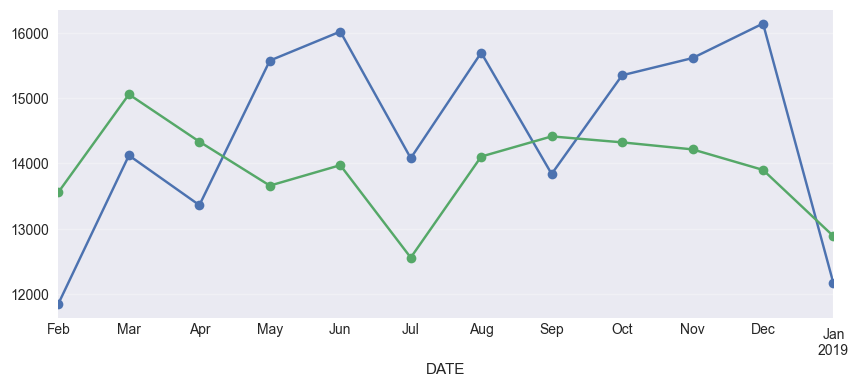

In [160]:
model = SARIMAX(train_x_st.Sales, order=(0, 0, 15)) 
model = model.fit(disp=False)

test_x['pred'] = model.forecast(steps=12)

# integrate it back to non-stationary level
test_x['pred'] = test_x['pred'].cumsum() + train_x.Sales[-1]

test_x['Sales'].plot(style='-o')
test_x['pred'].plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

### ARMA(p, q)

d:\Lens\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Lens\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Lens\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
d:\Lens\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
d:\Lens\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_re

MAE : 653.15
RMSE : 786.415
MAPE: 0.046


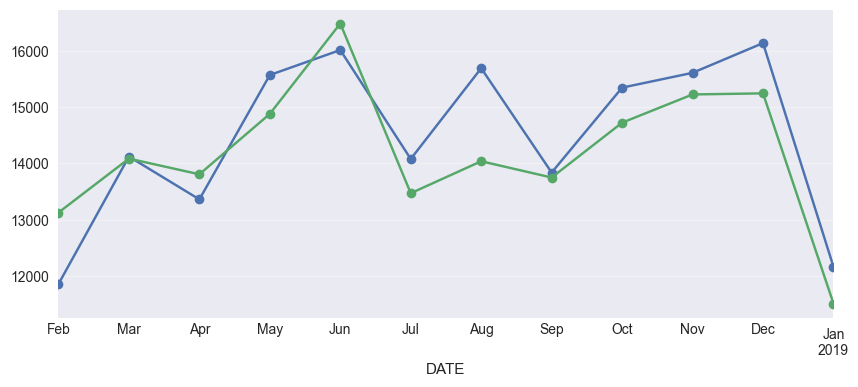

In [161]:
model = SARIMAX(train_x_st.Sales, order=(25, 0, 15)) 
model = model.fit(disp=False)

test_x['pred'] = model.forecast(steps=12)

# integrate it back to non-stationary level
test_x['pred'] = test_x['pred'].cumsum() + train_x.Sales[-1]

test_x['Sales'].plot(style='-o')
test_x['pred'].plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

### ARIMA (p,d,q)

d:\Lens\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Lens\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Lens\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE : 1372.679
RMSE : 1617.285
MAPE: 0.092


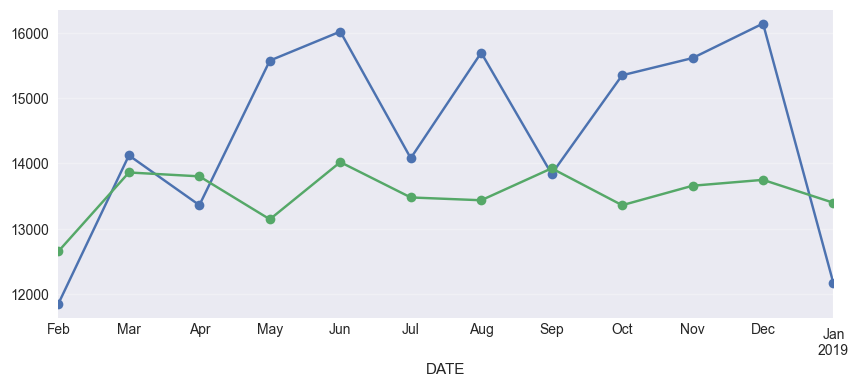

In [162]:
model = SARIMAX(train_x.Sales, order=(3, 1, 3)) 
model = model.fit(disp=False)

test_x['pred'] = model.forecast(steps=12)

test_x['Sales'].plot(style='-o')
test_x['pred'].plot(style='-o')
performance(test_x['Sales'], test_x['pred'])

### SARIMA (p,q,d,P,Q,D,s)

In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

d:\Lens\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Lens\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Lens\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


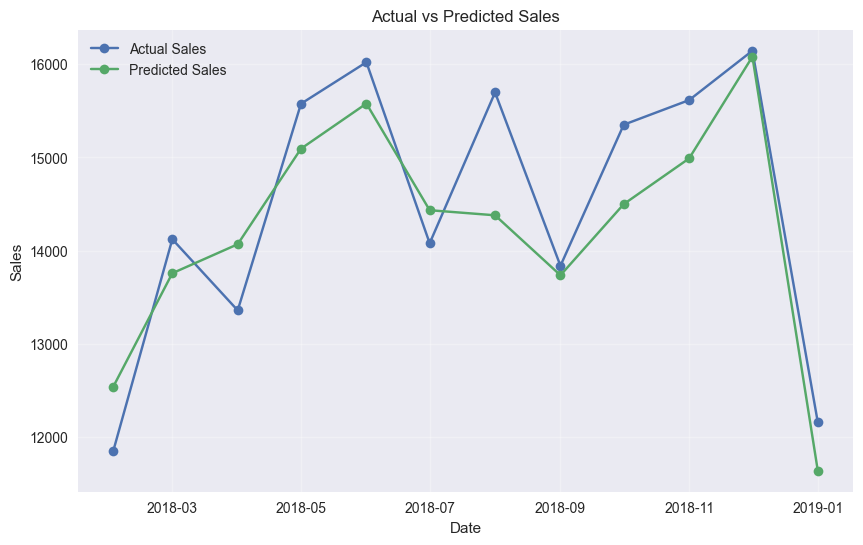

MAE : 543.492
RMSE : 632.541
MAPE: 0.038


In [164]:
# Fit SARIMAX model
sarimax_model = SARIMAX(train_x['Sales'], order=(5, 1, 3), seasonal_order=(1, 1, 1, 12))
sarimax_result = sarimax_model.fit(disp=False)

# Forecast for the test period
test_x['pred'] = sarimax_result.forecast(steps=12)

# Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.plot(test_x['Sales'], marker='o', linestyle='-', label='Actual Sales')
plt.plot(test_x['pred'], marker='o', linestyle='-', label='Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate performance
performance(test_x['Sales'], test_x['pred'])